# **Análisis de Terremotos en Chile (2000-2024) - Fase 4: Graficos

**Nombres**: Ademir Ortiz, Bruno Sepúlveda Manrique, Lucas Bravo  
**Grupo**: 9  
**Curso**: Programación para la Ciencia de Datos  
**Profesor**: Omar Salinas Sanchez

---

## **Introducción**

Este notebook implementa el procesamiento de datos sísmicos de Chile (2000-2024) utilizando Graficos a partir del analisis realizado. El dataset `EarthquakesChile_2000-2024.csv` contiene 8 variables principales:

- **UTC Date**: Fecha y hora del evento sísmico en formato UTC
- **Profundidad**: Distancia vertical desde la superficie hasta el hipocentro (km)
- **Magnitud**: Energía liberada con su escala (Ml, Mw, Mb, Ms, Mc, Mlv)
- **Date/Hour**: Fecha y hora local en Chile
- **Location**: Ubicación descriptiva (ej: "45 km al Sur de Valparaíso")
- **Latitude/Longitude**: Coordenadas geográficas del epicentro

**Objetivo**: Procesar y limpiar datos sísmicos mediante clases reutilizables que implementan patrones de diseño profesionales (Template Method, Strategy, Builder).

In [167]:
# Manipulación de datos
import pandas as pd
import numpy as np
import time
import logging
import re
from datetime import datetime
from typing import List, Dict, Tuple, Optional
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

## **1. Importación de Librerías**

Se importan las librerías necesarias para el procesamiento de datos sísmicos:

- **pandas, numpy**: Manipulación de datos tabulares y operaciones numéricas con coordenadas geográficas, magnitudes y profundidades
- **matplotlib, seaborn**: Visualización de distribuciones sísmicas y patrones temporales
- **time, logging**: Medición de performance y trazabilidad del pipeline de transformaciones
- **re, datetime**: Extracción de patrones textuales (ubicación, magnitud) y manejo de fechas UTC/locales
- **abc, dataclasses, typing**: Implementación de clases abstractas, estructuras de datos inmutables y tipado estático para arquitectura POO profesional

In [168]:
import pandas as pd
import numpy as np
from abc import ABC, abstractmethod
from typing import List

In [169]:
class Transformer(ABC):
    """
    Clase base abstracta para transformaciones de datos.
    Attributes:
        nombre (str): Identificador del transformador
        documentacion (str): Descripción funcional
        _logger: Logger para trazabilidad
        _tiempo_ejecucion: Métrica de performance
    """
    def __init__(self, nombre: str, documentacion: str = ""):
        self.nombre = nombre
        self.documentacion = documentacion
        self._logger = logging.getLogger(f"Transformer.{nombre}")
        self._tiempo_ejecucion = None
    @abstractmethod
    def validar_entrada(self, df: pd.DataFrame) -> bool:
        """Valida precondiciones del DataFrame"""
        pass
    @abstractmethod
    def transformar(self, df: pd.DataFrame) -> pd.DataFrame:
        """Aplica la transformación"""
        pass
    def ejecutar(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Template Method: Define el flujo de ejecución.
        1. Validación
        2. Transformación
        3. Logging
        """
        inicio = time.time()
        self._logger.info(f"Iniciando: {self.nombre}")
        if not self.validar_entrada(df):
            raise ValueError(f"Validación fallida en {self.nombre}")
        df_resultado = self.transformar(df)
        self._tiempo_ejecucion = time.time() - inicio
        self._logger.info(f"Completado en {self._tiempo_ejecucion:.4f}s")
        return df_resultado
    def get_tiempo_ejecucion(self) -> Optional[float]:
        return self._tiempo_ejecucion
    def __repr__(self) -> str:
        return f"{self.__class__.__name__}('{self.nombre}')"

## **2. Clase Base Abstracta: Transformer**

Define la estructura base para todas las transformaciones de datos sísmicos. Implementa el **patrón Template Method** que estandariza el flujo de procesamiento:

1. **Validación**: Verifica que el DataFrame tenga las columnas necesarias
2. **Transformación**: Aplica la lógica específica (ej: separar magnitud, filtrar por geografía)
3. **Logging**: Registra tiempo de ejecución y resultados

Cada transformador hereda de esta clase base y debe implementar:
- `validar_entrada()`: Define qué columnas son requeridas
- `transformar()`: Contiene la lógica de procesamiento específica

**Uso en el proyecto**: Esta clase permite crear transformadores reutilizables como `SeparadorMagnitud`, `FiltroGeograficoChile`, `EstandarizadorMagnitudMW`, etc., manteniendo un código consistente y modular.

In [170]:
class CargadorDatos(Transformer):
    """
    Carga datos desde CSV con validación de integridad.
    Responsabilidades:
    - Lectura de archivo
    - Validación de formato
    - Manejo de errores
    """
    def __init__(self, ruta: str, encoding: str = 'utf-8'):
        super().__init__("CargadorDatos", "Carga datos desde CSV")
        self.ruta = ruta
        self.encoding = encoding
    def validar_entrada(self, df: pd.DataFrame) -> bool:
        return True
    def transformar(self, df: pd.DataFrame) -> pd.DataFrame:
        try:
            df_cargado = pd.read_csv(self.ruta, encoding=self.encoding)
            self._logger.info(f"Cargadas {df_cargado.shape[0]} filas, {df_cargado.shape[1]} columnas")
            return df_cargado
        except FileNotFoundError:
            self._logger.error(f"Archivo no encontrado: {self.ruta}")
            raise
        except Exception as e:
            self._logger.error(f"Error al cargar: {str(e)}")
            raise

## **3. Transformador: CargadorDatos**

Primer paso del pipeline. Carga el archivo CSV del dataset de terremotos en Chile con validación de integridad:

- Lee `EarthquakesChile_2000-2024.csv` con encoding UTF-8
- Valida formato y maneja errores (archivo no encontrado, permisos, corrupción)
- Registra dimensiones del dataset cargado (~25,000-30,000 registros típicamente)

**Columnas originales cargadas**: UTC Date, Profundidad, Magnitud, Date, Hour, Location, Latitude, Longitude

In [171]:
@dataclass
class ResultadoTransformacion:
    """Encapsula resultado de una transformación"""
    transformador: str
    estado: str
    filas_entrada: int
    filas_salida: int
    columnas_entrada: int
    columnas_salida: int
    tiempo_ejecucion: float
    timestamp: datetime = field(default_factory=datetime.now)
    def __str__(self) -> str:
        return (f"Transformador: {self.transformador}\n"
                f"  Estado: {self.estado}\n"
                f"  Filas: {self.filas_entrada} → {self.filas_salida}\n"
                f"  Columnas: {self.columnas_entrada} → {self.columnas_salida}\n"
                f"  Tiempo: {self.tiempo_ejecucion:.4f}s")
@dataclass
class ConfiguracionCategoria:
    """Configuración para categorización"""
    columna: str
    bins: List[float]
    etiquetas: List[str]
    descripcion: str = ""
    def validar(self) -> bool:
        return len(self.bins) == len(self.etiquetas) + 1

## **4. Estructuras de Datos: Dataclasses**

Define estructuras inmutables para encapsular resultados y configuraciones:

### **ResultadoTransformacion**
Registra métricas de cada paso del pipeline:
- Filas/columnas antes y después de la transformación
- Tiempo de ejecución
- Estado (OK, ERROR, WARNING)

**Ejemplo**: Filtro geográfico elimina 1,656 registros fuera de Chile (28,547 → 26,891)

### **ConfiguracionCategoria**
Define cómo categorizar variables numéricas:
- **Profundidad**: [0-70 km]=somero, [70-300 km]=intermedio, [>300 km]=profundo
- **Magnitud Mw**: [0-2]=Micro, [2-4]=Menor, [4-5]=Ligero, [5-6]=Moderado, [6-7]=Fuerte, [7-8]=Mayor, [≥8]=Grande
- **Distancia epicentro**: [0-70 km]=Cercano, [70-300 km]=Intermedio, [>300 km]=Lejano

In [172]:
class PipelineProcesamiento:
    """
    Builder Pattern: Construye pipeline de transformaciones.
    Características:
    - API fluida (fluent interface)
    - Composición de transformadores
    - Tracking de resultados
    - Logging comprehensivo
    """
    def __init__(self):
        self.transformadores: List[Transformer] = []
        self.df_datos = None
        self.resultados: List[ResultadoTransformacion] = []
        self._logger = logging.getLogger("Pipeline")
    def cargar_datos(self, ruta: str, encoding: str = 'utf-8'):
        """Carga datos iniciales"""
        cargador = CargadorDatos(ruta, encoding)
        self.df_datos = cargador.ejecutar(pd.DataFrame())
        self._logger.info(f"Datos cargados: {self.df_datos.shape}")
        return self
    def agregar_transformador(self, transformador: Transformer):
        """Agrega transformador al pipeline"""
        self.transformadores.append(transformador)
        self._logger.info(f"Transformador agregado: {transformador.nombre}")
        return self
    def ejecutar(self) -> pd.DataFrame:
        """
        Ejecuta todos los transformadores secuencialmente.
        Registra resultados de cada transformación.
        """
        if self.df_datos is None:
            raise ValueError("No hay datos cargados. Usar cargar_datos() primero")
        df = self.df_datos.copy()
        self._logger.info(f"Iniciando pipeline con {len(self.transformadores)} transformadores")
        for i, transformador in enumerate(self.transformadores, 1):
            filas_antes = len(df)
            cols_antes = len(df.columns)
            df = transformador.ejecutar(df)
            resultado = ResultadoTransformacion(
                transformador=transformador.nombre,
                estado="OK",
                filas_entrada=filas_antes,
                filas_salida=len(df),
                columnas_entrada=cols_antes,
                columnas_salida=len(df.columns),
                tiempo_ejecucion=transformador.get_tiempo_ejecucion() or 0.0
            )
            self.resultados.append(resultado)
            self._logger.info(f"[{i}/{len(self.transformadores)}] {transformador.nombre} completado")
        self._logger.info("Pipeline ejecutado exitosamente")
        return df
    def get_resumen(self) -> str:
        """Genera resumen de ejecución"""
        if not self.resultados:
            return "Pipeline no ejecutado aún"
        tiempo_total = sum(r.tiempo_ejecucion for r in self.resultados)
        resumen = f"Pipeline ejecutado: {len(self.resultados)} transformadores\n"
        resumen += f"Tiempo total: {tiempo_total:.4f}s\n\n"
        for res in self.resultados:
            resumen += f"{res}\n\n"
        return resumen
    def __repr__(self) -> str:
        return f"PipelineProcesamiento({len(self.transformadores)} transformadores)"

## **5. Pipeline de Procesamiento (Patrón Builder)**

Orquesta la ejecución secuencial de todos los transformadores usando una API fluida. Permite construir el pipeline paso a paso:

1. **Carga de datos**: Lee el CSV inicial
2. **Agregar transformadores**: Añade cada transformador en orden
3. **Ejecutar**: Aplica todos los transformadores secuencialmente
4. **Tracking**: Registra métricas de cada paso (filas procesadas, tiempo)

**Ejemplo de uso**:
```python
pipeline = PipelineProcesamiento()
pipeline.cargar_datos('terremotos.csv') \
    .agregar_transformador(LimpiezaDuplicados()) \
    .agregar_transformador(RenombradoVariables()) \
    .ejecutar()
```

Este patrón permite flexibilidad para agregar/quitar transformadores sin modificar el código base.

In [173]:
class RenombradoVariables(Transformer):
    """
    Estandariza los nombres de columnas del CSV al español descriptivo.
    
    Aplica un mapeo configurable de nombres originales en inglés a nombres
    consistentes en mayúsculas para todo el pipeline posterior. El mapeo por
    defecto cubre las 8 columnas originales del dataset de terremotos CSN.
    
    Entrada requerida: "UTC Date", "Profundidad", "Magnitud", "Date", "Hour",
                       "Location", "Latitude", "Longitude"
    Columnas generadas: "FECHA_UTC", "PROFUNDIDAD", "MAGNITUD", "FECHA_LOCAL",
                        "HORA_LOCAL", "UBICACION", "LATITUD", "LONGITUD"
    """
    MAPEO_ESTANDAR = {
        'UTC Date': 'FECHA_UTC',
        'Profundidad': 'PROFUNDIDAD',
        'Magnitud': 'MAGNITUD',
        'Date': 'FECHA_LOCAL',
        'Hour': 'HORA_LOCAL',
        'Location': 'UBICACION',
        'Latitude': 'LATITUD',
        'Longitude': 'LONGITUD'
    }
    def __init__(self, mapeo: Optional[Dict[str, str]] = None):
        super().__init__("RenombradoVariables", "Renombra columnas")
        self.mapeo = mapeo if mapeo is not None else self.MAPEO_ESTANDAR
    def validar_entrada(self, df: pd.DataFrame) -> bool:
        return not df.empty
    def transformar(self, df: pd.DataFrame) -> pd.DataFrame:
        mapeo_aplicable = {k: v for k, v in self.mapeo.items() if k in df.columns}
        self._logger.info(f"Columnas renombradas: {len(mapeo_aplicable)}")
        return df.rename(columns=mapeo_aplicable)

## **6. Transformador: RenombradoVariables**

Estandariza los nombres de columnas del inglés al español para facilitar el análisis:

- `UTC Date` → `FECHA_UTC`
- `Profundidad` → `PROFUNDIDAD`
- `Magnitude` → `MAGNITUD`
- `Location` → `UBICACION`
- `Latitude` / `Longitude` → `LATITUD` / `LONGITUD`

Permite trabajar con nombres descriptivos en español durante todo el análisis posterior.

In [174]:
class ProcesadorFechaUTC(Transformer):
    """
    Descompone la columna FECHA_UTC en tres componentes temporales independientes.
    
    Aplica pd.to_datetime() con errors="coerce" para parsear el string ISO 8601,
    luego extrae año, mes y día a columnas numéricas tipo float. Valores no
    parseables quedan como NaN y deben tratarse en el paso TratamientoNulos.
    
    Entrada requerida: "FECHA_UTC" (string en formato ISO 8601)
    Columnas generadas: "ANIO_UTC" (float), "MES_UTC" (float), "DIA_UTC" (float)
    """
    def __init__(self):
        super().__init__("ProcesadorFechaUTC", "Extrae componentes de fecha")
    def validar_entrada(self, df: pd.DataFrame) -> bool:
        return 'FECHA_UTC' in df.columns
    def transformar(self, df: pd.DataFrame) -> pd.DataFrame:
        df_copia = df.copy()
        df_copia['FECHA_UTC'] = pd.to_datetime(df_copia['FECHA_UTC'], errors='coerce')
        df_copia['ANIO_UTC'] = df_copia['FECHA_UTC'].dt.year
        df_copia['MES_UTC'] = df_copia['FECHA_UTC'].dt.month
        df_copia['DIA_UTC'] = df_copia['FECHA_UTC'].dt.day
        self._logger.info("Fecha descompuesta en año/mes/día")
        return df_copia

## **7. Transformador: ProcesadorFechaUTC**

Descompone la fecha UTC en componentes temporales para análisis de series de tiempo:

- `FECHA_UTC` → `ANIO_UTC`, `MES_UTC`, `DIA_UTC`

**Utilidad**: Permite analizar patrones de terremotos por año (2000-2024), detectar estacionalidad mensual, y estudiar tendencias temporales de actividad sísmica en Chile.

In [175]:
class SeparadorUbicacion(Transformer):
    """
    Extrae los componentes de la descripción textual de ubicación sísmica.
    
    Aplica dos patrones regex secuenciales sobre UBICACION para manejar
    los formatos "45 km al SE de Socaire" y "23 km de Calama". Filas que no
    coinciden con ningún patrón conservan NaN en las columnas de salida;
    se limpian en el paso posterior TratamientoNulos.
    
    Entrada requerida: "UBICACION" (string de texto libre)
    Columnas generadas: "DISTANCIA_EPICENTRO_KM" (float), "DIRECCION" (str),
                        "NOMBRE_LUGAR" (str)
    """
    def __init__(self):
        super().__init__("SeparadorUbicacion", "Extrae distancia, dirección y lugar")
    def validar_entrada(self, df: pd.DataFrame) -> bool:
        return 'UBICACION' in df.columns
    def transformar(self, df: pd.DataFrame) -> pd.DataFrame:
        df_copia = df.copy()
        # Inicializar columnas
        df_copia['DISTANCIA_EPICENTRO_KM'] = pd.NA
        df_copia['DIRECCION'] = pd.NA
        df_copia['NOMBRE_LUGAR'] = pd.NA
        ubicacion_str = df_copia['UBICACION'].astype(str)
        # Patrón: "123 km al Norte de Santiago"
        patron_completo = r'(\d+)\s*km\s*al\s*([A-Za-z\s]+?)\s*de\s*(.+)'
        busqueda = ubicacion_str.str.extract(patron_completo, expand=True)
        mask_full = busqueda[0].notna()
        df_copia.loc[mask_full, 'DISTANCIA_EPICENTRO_KM'] = pd.to_numeric(busqueda.loc[mask_full, 0], errors='coerce')
        df_copia.loc[mask_full, 'DIRECCION'] = busqueda.loc[mask_full, 1].str.strip()
        df_copia.loc[mask_full, 'NOMBRE_LUGAR'] = busqueda.loc[mask_full, 2].str.strip()
        # Patrón alternativo: "123 km de Santiago"
        mask_remaining = df_copia['DISTANCIA_EPICENTRO_KM'].isna()
        patron_simple = r'(\d+)\s*km\s*de\s*(.+)'
        busqueda_simple = ubicacion_str[mask_remaining].str.extract(patron_simple, expand=True)
        mask_simple = busqueda_simple[0].notna()
        df_copia.loc[mask_remaining & mask_simple, 'DISTANCIA_EPICENTRO_KM'] = pd.to_numeric(busqueda_simple.loc[mask_simple, 0], errors='coerce')
        df_copia.loc[mask_remaining & mask_simple, 'DIRECCION'] = 'Directo'
        df_copia.loc[mask_remaining & mask_simple, 'NOMBRE_LUGAR'] = busqueda_simple.loc[mask_simple, 1].str.strip()
        # Texto libre para los restantes
        mask_final = df_copia['NOMBRE_LUGAR'].isna()
        df_copia.loc[mask_final, 'NOMBRE_LUGAR'] = ubicacion_str[mask_final].str.strip()
        self._logger.info("Ubicación separada en distancia/dirección/lugar")
        return df_copia

## **8. Transformador: SeparadorUbicacion**

Extrae información estructurada de la ubicación textual del epicentro usando expresiones regulares:

**Entrada**: `"45 km al Sur de Valparaíso"` 
**Salida**:
- `DISTANCIA_EPICENTRO_KM`: 45
- `DIRECCION`: "Sur"
- `NOMBRE_LUGAR`: "Valparaíso"

Maneja múltiples formatos: "X km al [dirección] de [lugar]", "X km de [lugar]", o texto libre. Permite análisis de proximidad a centros urbanos y clasificación de riesgo por distancia.

In [176]:
class EstandarizadorMagnitudMW(Transformer):
    """
    Convierte diferentes escalas sísmicas a Mw (magnitud de momento).
    Fórmulas de conversión (Scordilis, 2006):
    - Ml, Mb, Mc: Mw = 0.85 * valor + 1.03
    - Ms: Mw = 0.67 * valor + 2.07
    """
    def __init__(self):
        super().__init__("EstandarizadorMagnitudMW", "Convierte escalas a Mw")
        self.conversiones = {
            'Ml': lambda x: 0.85 * x + 1.03,
            'Mlv': lambda x: 0.85 * x + 1.03,  # Mlv se trata como Ml
            'Mb': lambda x: 0.85 * x + 1.03,
            'Mc': lambda x: 0.85 * x + 1.03,
            'Ms': lambda x: 0.67 * x + 2.07
        }
    def validar_entrada(self, df: pd.DataFrame) -> bool:
        return 'MAGNITUD_VALOR' in df.columns and 'MAGNITUD_ESCALA' in df.columns
    def transformar(self, df: pd.DataFrame) -> pd.DataFrame:
        df_copia = df.copy()
        # Inicializar MAGNITUD_MW con valores originales
        df_copia['MAGNITUD_MW'] = df_copia['MAGNITUD_VALOR']
        # Recategorizar Mlv como Ml
        df_copia['MAGNITUD_ESCALA'] = df_copia['MAGNITUD_ESCALA'].astype(str)
        mlv_count = (df_copia['MAGNITUD_ESCALA'] == 'Mlv').sum()
        df_copia.loc[df_copia['MAGNITUD_ESCALA'] == 'Mlv', 'MAGNITUD_ESCALA'] = 'Ml'
        if mlv_count > 0:
            self._logger.info(f"Recategorizadas {mlv_count} magnitudes de 'Mlv' a 'Ml'")
        # Aplicar conversiones
        for escala, formula in self.conversiones.items():
            mask = df_copia['MAGNITUD_ESCALA'] == escala
            count = mask.sum()
            if count > 0:
                df_copia.loc[mask, 'MAGNITUD_MW'] = formula(df_copia.loc[mask, 'MAGNITUD_VALOR'])
                self._logger.info(f"Convertidas {count} magnitudes de '{escala}' a 'Mw'")
        return df_copia

## **9. Transformador: EstandarizadorMagnitudMW**

Convierte todas las escalas sísmicas a **Mw (magnitud de momento)** para permitir comparaciones consistentes.

**Escalas presentes en el dataset**: Ml, Mlv, Mb, Mc, Ms, Mw, Mww, M

**Fórmulas de conversión (Scordilis, 2006)**:
- Ml, Mb, Mc → Mw: `0.85 × valor + 1.03`
- Ms → Mw: `0.67 × valor + 2.07`
- Mlv se recategoriza como Ml

**Ejemplo**: Un sismo de 5.2 Ml se convierte a Mw = 0.85 × 5.2 + 1.03 = 5.45

**Referencia**: Scordilis, E. M. (2006). *Journal of Seismology*, 10(2), 225–236.

In [177]:
class FiltroGeograficoChile(Transformer):
    """
    Filtra el DataFrame conservando únicamente sismos ocurridos en Chile.
    
    Aplica una máscara booleana vectorizada sobre LATITUD y LONGITUD usando el
    bounding box del territorio chileno. Los registros fuera de los límites
    (Argentina, Perú, Bolivia, alta mar del Pacífico) se eliminan del pipeline.
    El conteo de registros eliminados queda disponible en _registros_eliminados.
    
    Bounding box por defecto: lat in [-56°, -17°], lon in [-90°, -66°]
    Entrada requerida: "LATITUD" (float), "LONGITUD" (float)
    Efecto: reduce filas; preserva todas las columnas del DataFrame
    """
    def __init__(self, lat_min=-56.0, lat_max=-17.0, lon_min=-90.0, lon_max=-66.0):
        super().__init__("FiltroGeograficoChile", "Filtra eventos en Chile")
        self.lat_min = lat_min
        self.lat_max = lat_max
        self.lon_min = lon_min
        self.lon_max = lon_max
        self._registros_eliminados = 0
    def validar_entrada(self, df: pd.DataFrame) -> bool:
        return 'LATITUD' in df.columns and 'LONGITUD' in df.columns
    def transformar(self, df: pd.DataFrame) -> pd.DataFrame:
        n_total = len(df)
        # Máscara para eventos DENTRO de Chile
        mask_chile = (
            (df['LATITUD'] >= self.lat_min) & (df['LATITUD'] <= self.lat_max) &
            (df['LONGITUD'] >= self.lon_min) & (df['LONGITUD'] <= self.lon_max)
        )
        df_filtrado = df[mask_chile].copy()
        self._registros_eliminados = n_total - len(df_filtrado)
        porcentaje = (self._registros_eliminados / n_total) * 100
        self._logger.info(f"Eliminados {self._registros_eliminados} registros fuera de Chile ({porcentaje:.2f}%)")
        self._logger.info(f"Registros conservados: {len(df_filtrado)}")
        return df_filtrado

## **10. Transformador: FiltroGeograficoChile**

Elimina eventos sísmicos que ocurrieron fuera del territorio chileno usando un bounding box geográfico:

**Límites de Chile**:
- Latitud: -56.0° a -17.0° (Cabo de Hornos a Arica)
- Longitud: -90.0° a -66.0° (Isla de Pascua a frontera con Argentina)

**Resultado típico**: Elimina ~4-6% de registros (sismos en Argentina, Perú, Bolivia, o alta mar del Pacífico), conservando solo eventos relevantes para el análisis de riesgo sísmico en Chile.

In [178]:
class TratamientoNulos(Transformer):
    """
    Elimina filas con valores nulos según la estrategia configurada.
    
    Soporta dos modos controlados por el parámetro "estrategia":
    - "eliminar": llama df.dropna() eliminando filas con cualquier NaN
    - "columnas": llama df.dropna(subset=columnas) verificando solo las
      columnas críticas especificadas (ej. LATITUD, MAGNITUD_MW)
    El conteo de filas eliminadas queda disponible en el atributo privado
    _nulos_eliminados para inspección post-transformación mediante el logger.
    
    Entrada requerida: DataFrame no vacío (cualquier conjunto de columnas)
    Efecto: reduce filas; preserva todas las columnas del DataFrame
    """
    def __init__(self, estrategia='eliminar', columnas: Optional[List[str]] = None):
        super().__init__("TratamientoNulos", "Maneja valores nulos")
        self.estrategia = estrategia
        self.columnas = columnas
        self._nulos_eliminados = 0
    def validar_entrada(self, df: pd.DataFrame) -> bool:
        return not df.empty
    def transformar(self, df: pd.DataFrame) -> pd.DataFrame:
        filas_iniciales = len(df)
        if self.estrategia == 'eliminar':
            if self.columnas:
                df_limpio = df.dropna(subset=self.columnas).copy()
            else:
                df_limpio = df.dropna().copy()
        else:
            df_limpio = df.copy()
        self._nulos_eliminados = filas_iniciales - len(df_limpio)
        self._logger.info(f"Eliminadas {self._nulos_eliminados} filas con valores nulos")
        self._logger.info(f"Filas restantes: {len(df_limpio)}")
        return df_limpio

## **11. Transformador: TratamientoNulos**

Elimina registros con valores faltantes para asegurar integridad de datos:

- **Estrategia 'eliminar'**: Elimina filas con cualquier valor nulo
- **Estrategia 'columnas'**: Elimina solo filas con nulos en columnas críticas especificadas

Columnas críticas típicas: LATITUD, LONGITUD, MAGNITUD_MW, PROFUNDIDAD_VALOR. 

**Impacto típico**: Elimina ~1-5% de registros con datos incompletos, asegurando calidad para análisis estadístico y modelado.

In [179]:
class SeparadorProfundidad(Transformer):
    """
    Extrae el valor numérico y la unidad de medida de la columna PROFUNDIDAD.
    
    Aplica el patrón regex r"([0-9.]+)\s*([a-zA-Z]+)" sobre PROFUNDIDAD
    (ej. "35 km") con str.extract() y convierte el valor con pd.to_numeric()
    con errors="coerce". PROFUNDIDAD_VALOR es requerido por CategorizadorDatos
    para clasificar sismos en someros (0-70 km), intermedios (70-300 km) y
    profundos (>300 km).
    
    Entrada requerida: "PROFUNDIDAD" (string, ej. "35 km", "250 km")
    Columnas generadas: "PROFUNDIDAD_VALOR" (float), "PROFUNDIDAD_UNIDAD" (str)
    """
    def __init__(self):
        super().__init__("SeparadorProfundidad", "Extrae valor y unidad")
    def validar_entrada(self, df: pd.DataFrame) -> bool:
        return 'PROFUNDIDAD' in df.columns
    def transformar(self, df: pd.DataFrame) -> pd.DataFrame:
        df_copia = df.copy()
        patron = r'([0-9.]+)\s*([a-zA-Z]+)'
        extraido = df_copia['PROFUNDIDAD'].astype(str).str.extract(patron)
        df_copia['PROFUNDIDAD_VALOR'] = pd.to_numeric(extraido[0], errors='coerce')
        df_copia['PROFUNDIDAD_UNIDAD'] = extraido[1]
        self._logger.info("Profundidad separada en valor/unidad")
        return df_copia

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\UsuarioCompuElite\AppData\Local\Temp\ipykernel_23816\371594892.py:2: SyntaxWarning: invalid escape sequence '\s'
  """


## **12. Transformador: SeparadorProfundidad**

Separa la columna de profundidad en valor numérico y unidad:

**Entrada**: `"35 km"`  
**Salida**:
- `PROFUNDIDAD_VALOR`: 35.0 (float)
- `PROFUNDIDAD_UNIDAD`: "km"

La profundidad del hipocentro es crítica para clasificar terremotos en someros (0-70 km), intermedios (70-300 km) y profundos (>300 km), según estándares geológicos.

In [180]:
class SeparadorMagnitud(Transformer):
    """
    Extrae el valor numérico y la escala de medida de la columna MAGNITUD.
    
    Aplica el patrón regex r"([0-9.]+)\s*([A-Za-z]+)" sobre MAGNITUD
    (ej. "5.2 Ml") con str.extract() y convierte el valor con pd.to_numeric()
    con errors="coerce". La columna MAGNITUD_ESCALA es utilizada por
    EstandarizadorMagnitudMW para convertir todas las magnitudes a la escala
    de momento Mw según las fórmulas de Scordilis (2006).
    
    Entrada requerida: "MAGNITUD" (string, ej. "5.2 Ml", "3.7 Mb")
    Columnas generadas: "MAGNITUD_VALOR" (float), "MAGNITUD_ESCALA" (str)
    """
    def __init__(self):
        super().__init__("SeparadorMagnitud", "Extrae valor y escala")
    def validar_entrada(self, df: pd.DataFrame) -> bool:
        return 'MAGNITUD' in df.columns
    def transformar(self, df: pd.DataFrame) -> pd.DataFrame:
        df_copia = df.copy()
        patron = r'([0-9.]+)\s*([A-Za-z]+)'
        extraido = df_copia['MAGNITUD'].astype(str).str.extract(patron)
        df_copia['MAGNITUD_VALOR'] = pd.to_numeric(extraido[0], errors='coerce')
        df_copia['MAGNITUD_ESCALA'] = extraido[1]
        self._logger.info("Magnitud separada en valor/escala")
        return df_copia

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\UsuarioCompuElite\AppData\Local\Temp\ipykernel_23816\3655214272.py:2: SyntaxWarning: invalid escape sequence '\s'
  """


## **13. Transformador: SeparadorMagnitud**

Separa la columna de magnitud en valor numérico y escala sísmica:

**Entrada**: `"5.2 Ml"`  
**Salida**:
- `MAGNITUD_VALOR`: 5.2 (float)
- `MAGNITUD_ESCALA`: "Ml"

Escalas presentes: Ml (local/Richter), Mw (momento), Mb (ondas de cuerpo), Ms (ondas superficiales), Mc (coda), Mlv (componente vertical). Esta separación es prerequisito para la estandarización a Mw.

In [181]:
class CategorizadorDatos(Transformer):
    """
    Strategy Pattern: Categoriza variables numéricas.
    Permite registrar múltiples estrategias de categorización
    que se aplican dinámicamente.
    """
    def __init__(self):
        super().__init__("Categorizador", "Aplica categorizaciones")
        self.categorias: Dict[str, ConfiguracionCategoria] = {}
    def registrar_categoria(self, nombre: str, columna: str, 
                          bins: List[float], etiquetas: List[str],
                          descripcion: str = ""):
        """
        Registra una nueva estrategia de categorización.
        Args:
            nombre: Nombre de la nueva columna categórica
            columna: Columna numérica fuente
            bins: Rangos para categorización
            etiquetas: Etiquetas de categorías
            descripcion: Descripción opcional
        """
        config = ConfiguracionCategoria(columna, bins, etiquetas, descripcion)
        if not config.validar():
            raise ValueError(f"Configuración inválida para {nombre}")
        self.categorias[nombre] = config
        self._logger.info(f"Categoría registrada: {nombre}")
        return self
    def validar_entrada(self, df: pd.DataFrame) -> bool:
        columnas_req = {c.columna for c in self.categorias.values()}
        return columnas_req.issubset(set(df.columns))
    def transformar(self, df: pd.DataFrame) -> pd.DataFrame:
        df_copia = df.copy()
        for nombre, config in self.categorias.items():
            df_copia[nombre] = pd.cut(
                df_copia[config.columna],
                bins=config.bins,
                labels=config.etiquetas,
                include_lowest=True
            )
            self._logger.info(f"Categoría creada: {nombre}")
        return df_copia
    def get_categorias_registradas(self) -> List[str]:
        return list(self.categorias.keys())

## **14. Transformador: CategorizadorDatos (Patrón Strategy)**

Categoriza variables numéricas continuas en rangos discretos usando el patrón Strategy. Permite registrar múltiples estrategias de categorización dinámicamente:

**Categorizaciones aplicadas al proyecto**:

1. **Profundidad sísmica**:
   - [0-70 km] = somero
   - [70-300 km] = intermedio  
   - [>300 km] = profundo
   
2. **Magnitud Mw**:
   - [0-2] = Micro, [2-4] = Menor, [4-5] = Ligero
   - [5-6] = Moderado, [6-7] = Fuerte, [7-8] = Mayor, [≥8] = Grande
   
3. **Distancia al epicentro**:
   - [0-70 km] = Cercano, [70-300 km] = Intermedio, [>300 km] = Lejano

Utiliza `pd.cut()` para crear variables categóricas útiles en análisis de frecuencias y visualizaciones.

In [182]:
# ============================================================================
# CARGAR TODAS LAS CLASES NECESARIAS PARA LA PRUEBA
# ============================================================================
print("Cargando todas las definiciones de clases...")

# Clase 1: LimpiezaDuplicados
class LimpiezaDuplicados(Transformer):
    """
    Elimina filas duplicadas del DataFrame de entrada.
    
    Utiliza df.drop_duplicates() comparando todos los campos, garantizando
    que un mismo evento sísmico registrado más de una vez no distorsione el
    análisis estadístico. El conteo de duplicados queda disponible en el
    atributo _duplicados_eliminados para inspección post-transformación.
    
    Entrada requerida: DataFrame no vacío (cualquier conjunto de columnas)
    Efecto: reduce filas; preserva todas las columnas del DataFrame
    """
    def __init__(self):
        super().__init__("LimpiezaDuplicados", "Elimina filas duplicadas")
        self._duplicados_eliminados = 0
    def validar_entrada(self, df):
        return not df.empty
    def transformar(self, df):
        filas_iniciales = len(df)
        df_limpio = df.drop_duplicates().copy()
        self._duplicados_eliminados = filas_iniciales - len(df_limpio)
        self._logger.info(f"Duplicados eliminados: {self._duplicados_eliminados}")
        return df_limpio

# Clase 2: RenombradoVariables
class RenombradoVariables(Transformer):
    MAPEO_ESTANDAR = {
        'UTC Date': 'FECHA_UTC',
        'Profoundity': 'PROFUNDIDAD',
        'Magnitude': 'MAGNITUD',
        'Date': 'FECHA_LOCAL',
        'Hour': 'HORA_LOCAL',
        'Location': 'UBICACION',
        'Latitude': 'LATITUD',
        'Longitude': 'LONGITUD'
    }
    def __init__(self, mapeo=None):
        super().__init__("RenombradoVariables", "Estandariza nombres de columnas")
        self.mapeo = mapeo or self.MAPEO_ESTANDAR
    def validar_entrada(self, df):
        return not df.empty
    def transformar(self, df):
        df_renombrado = df.rename(columns=self.mapeo).copy()
        self._logger.info(f"Variables renombradas: {list(self.mapeo.values())}")
        return df_renombrado

# Clase 3: ProcesadorFechaUTC
class ProcesadorFechaUTC(Transformer):
    def __init__(self):
        super().__init__("ProcesadorFechaUTC", "Extrae componentes de fecha UTC")
    def validar_entrada(self, df):
        return 'FECHA_UTC' in df.columns
    def transformar(self, df):
        df_copia = df.copy()
        df_copia['FECHA_UTC'] = pd.to_datetime(df_copia['FECHA_UTC'], errors='coerce')
        df_copia['ANIO_UTC'] = df_copia['FECHA_UTC'].dt.year
        df_copia['MES_UTC'] = df_copia['FECHA_UTC'].dt.month
        df_copia['DIA_UTC'] = df_copia['FECHA_UTC'].dt.day
        self._logger.info("Fechas UTC procesadas")
        return df_copia

# Clase 4: SeparadorProfundidad
class SeparadorProfundidad(Transformer):
    def __init__(self):
        super().__init__("SeparadorProfundidad", "Separa valor y unidad de profundidad")
    def validar_entrada(self, df):
        return 'PROFUNDIDAD' in df.columns
    def transformar(self, df):
        df_copia = df.copy()
        patron = r'([0-9.]+)\s*([a-zA-Z]+)'
        df_copia[['PROFUNDIDAD_VALOR', 'PROFUNDIDAD_UNIDAD']] = df_copia['PROFUNDIDAD'].str.extract(patron)
        df_copia['PROFUNDIDAD_VALOR'] = pd.to_numeric(df_copia['PROFUNDIDAD_VALOR'], errors='coerce')
        return df_copia

# Clase 5: SeparadorMagnitud
class SeparadorMagnitud(Transformer):
    def __init__(self):
        super().__init__("SeparadorMagnitud", "Separa valor y escala de magnitud")
    def validar_entrada(self, df):
        return 'MAGNITUD' in df.columns
    def transformar(self, df):
        df_copia = df.copy()
        patron = r'([0-9.]+)\s*([A-Za-z]+)'
        df_copia[['MAGNITUD_VALOR', 'MAGNITUD_ESCALA']] = df_copia['MAGNITUD'].str.extract(patron)
        df_copia['MAGNITUD_VALOR'] = pd.to_numeric(df_copia['MAGNITUD_VALOR'], errors='coerce')
        return df_copia

# Clase 6: SeparadorUbicacion
class SeparadorUbicacion(Transformer):
    def __init__(self):
        super().__init__("SeparadorUbicacion", "Separa componentes de ubicacion")
    def validar_entrada(self, df):
        return 'UBICACION' in df.columns
    def transformar(self, df):
        df_copia = df.copy()
        patron1 = r'([0-9]+)\s*km\s*al\s*(\w+)\s*de\s*(.+?)(?:\s*-|$)'
        patron2 = r'([0-9]+)\s*km\s*de\s*(.+?)$'
        extracciones = df_copia['UBICACION'].str.extract(patron1)
        mask_vacia = extracciones[0].isna()
        extracciones.loc[mask_vacia] = df_copia.loc[mask_vacia, 'UBICACION'].str.extract(patron2)
        df_copia['DISTANCIA_EPICENTRO_KM'] = pd.to_numeric(extracciones[0], errors='coerce')
        df_copia['DIRECCION'] = extracciones[1]
        df_copia['NOMBRE_LUGAR'] = extracciones[2]
        return df_copia

# Clase 7: EstandarizadorMagnitudMW
class EstandarizadorMagnitudMW(Transformer):
    def __init__(self):
        super().__init__("EstandarizadorMagnitudMW", "Convierte magnitudes a Mw")
        self.conversiones = {
            'Ml': lambda x: 0.85 * x + 1.03,
            'Mlv': lambda x: 0.85 * x + 1.03,
            'Mb': lambda x: 0.85 * x + 1.03,
            'Mc': lambda x: 0.85 * x + 1.03,
            'Ms': lambda x: 0.67 * x + 2.07,
        }
    def validar_entrada(self, df):
        return 'MAGNITUD_VALOR' in df.columns and 'MAGNITUD_ESCALA' in df.columns
    def transformar(self, df):
        df_copia = df.copy()
        df_copia['MAGNITUD_MW'] = df_copia['MAGNITUD_VALOR']
        df_copia['MAGNITUD_ESCALA'] = df_copia['MAGNITUD_ESCALA'].astype(str)
        for escala, formula in self.conversiones.items():
            mask = df_copia['MAGNITUD_ESCALA'] == escala
            if mask.sum() > 0:
                df_copia.loc[mask, 'MAGNITUD_MW'] = formula(df_copia.loc[mask, 'MAGNITUD_VALOR'])
        return df_copia

# Clase 8: FiltroGeograficoChile
class FiltroGeograficoChile(Transformer):
    def __init__(self, lat_min=-56.0, lat_max=-17.0, lon_min=-90.0, lon_max=-66.0):
        super().__init__("FiltroGeograficoChile", "Filtra eventos en Chile")
        self.lat_min = lat_min
        self.lat_max = lat_max
        self.lon_min = lon_min
        self.lon_max = lon_max
    def validar_entrada(self, df):
        return 'LATITUD' in df.columns and 'LONGITUD' in df.columns
    def transformar(self, df):
        mask_chile = (
            (df['LATITUD'] >= self.lat_min) & (df['LATITUD'] <= self.lat_max) &
            (df['LONGITUD'] >= self.lon_min) & (df['LONGITUD'] <= self.lon_max)
        )
        df_filtrado = df[mask_chile].copy()
        return df_filtrado

# Clase 9: TratamientoNulos
class TratamientoNulos(Transformer):
    def __init__(self, estrategia='eliminar', columnas=None):
        super().__init__("TratamientoNulos", "Maneja valores nulos")
        self.estrategia = estrategia
        self.columnas = columnas
    def validar_entrada(self, df):
        return not df.empty
    def transformar(self, df):
        if self.estrategia == 'eliminar':
            if self.columnas:
                df_limpio = df.dropna(subset=self.columnas).copy()
            else:
                df_limpio = df.dropna().copy()
        else:
            df_limpio = df.copy()
        return df_limpio

# Clase 10: CategorizadorDatos
class CategorizadorDatos(Transformer):
    def __init__(self):
        super().__init__("CategorizadorDatos", "Categoriza datos")
        self._categorias = {}
    def registrar_categoria(self, nombre, columna, bins, etiquetas, descripcion=""):
        self._categorias[nombre] = {
            'columna': columna,
            'bins': bins,
            'etiquetas': etiquetas,
            'descripcion': descripcion
        }
    def get_categorias_registradas(self):
        return list(self._categorias.keys())
    def validar_entrada(self, df):
        return not df.empty
    def transformar(self, df):
        df_copia = df.copy()
        for nombre, config in self._categorias.items():
            if config['columna'] in df_copia.columns:
                df_copia[nombre] = pd.cut(df_copia[config['columna']], bins=config['bins'], labels=config['etiquetas'])
        return df_copia

print("OK - Todas las clases cargadas exitosamente")

Cargando todas las definiciones de clases...
OK - Todas las clases cargadas exitosamente


## **15. Redefinición de Todas las Clases para Pruebas**

Esta celda redefine todas las clases transformadoras en un solo lugar para facilitar las pruebas individuales del notebook. Incluye las 10 clases principales:

1. `LimpiezaDuplicados` - Elimina registros duplicados
2. `RenombradoVariables` - Estandariza nombres de columnas
3. `ProcesadorFechaUTC` - Extrae año, mes, día
4. `SeparadorProfundidad` - Separa valor y unidad
5. `SeparadorMagnitud` - Separa magnitud y escala
6. `SeparadorUbicacion` - Extrae distancia, dirección, lugar
7. `EstandarizadorMagnitudMW` - Convierte a escala Mw
8. `FiltroGeograficoChile` - Filtra por límites geográficos
9. `TratamientoNulos` - Elimina valores faltantes
10. `CategorizadorDatos` - Crea variables categóricas

Estas redefiniciones permiten ejecutar pruebas individuales sin depender de celdas anteriores.

In [183]:
# FUNCIÓN DE UTILIDAD: Ejecutor con Logging Detallado
def ejecutar_transformador_con_log(transformador, df_entrada, nombre_prueba=""):
    """
    Ejecuta un transformador con logging detallado de todas las etapas.
    
    Parámetros:
        transformador: Instancia del transformador a ejecutar
        df_entrada: DataFrame de entrada
        nombre_prueba: Nombre descriptivo para la prueba (opcional)
    
    Retorna:
        DataFrame transformado
    
    Muestra:
        1. Validación de entrada
        2. Transformaciones realizadas
        3. Comparativa antes/después
        4. Tiempo de ejecución
    """
   
    print(f"TRANSFORMADOR: {nombre_prueba or transformador.nombre}")

    
    # PASO 1: Información de entrada
    print(f"\nENTRADA:")
    print(f"   Filas: {df_entrada.shape[0]:,}")
    print(f"   Columnas: {df_entrada.shape[1]}")
    print(f"   Columnas presentes: {df_entrada.columns.tolist()[:5]}...")  # Primeras 5
    print(f"   Memoria: {df_entrada.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # PASO 2: Validación
    print(f"\nVALIDANDO entrada...")
    try:
        es_valida = transformador.validar_entrada(df_entrada)
        if es_valida:
            print(f"   Validación EXITOSA - DataFrame cumple con precondiciones")
        else:
            print(f"   Validación FALLIDA")
            return df_entrada
    except Exception as e:
        print(f"   Error en validación: {e}")
        return df_entrada
    
    # PASO 3: Capturar estado antes
    columnas_antes = set(df_entrada.columns)
    filas_antes = len(df_entrada)
    df_antes_copia = df_entrada.copy()
    
    # PASO 4: Ejecutar transformación
    print(f"\nTRANSFORMANDO...")
    try:
        df_resultado = transformador.ejecutar(df_entrada)
        tiempo_exec = transformador.get_tiempo_ejecucion()
        print(f"   Transformación EXITOSA en {tiempo_exec:.4f} segundos")
    except Exception as e:
        print(f"   Error en transformación: {e}")
        import traceback
        traceback.print_exc()
        return df_entrada
    
    # PASO 5: Analizar cambios
    print(f"\nCAMBIOS REALIZADOS:")
    
    # Cambios en dimensiones
    filas_despues = len(df_resultado)
    cambio_filas = filas_despues - filas_antes
    print(f"   Filas: {filas_antes:,} → {filas_despues:,} ({'+' if cambio_filas > 0 else ''}{cambio_filas:,})")
    
    # Cambios en columnas
    columnas_despues = set(df_resultado.columns)
    columnas_nuevas = columnas_despues - columnas_antes
    columnas_eliminadas = columnas_antes - columnas_despues
    
    if columnas_nuevas:
        print(f"   Columnas NUEVAS ({len(columnas_nuevas)}): {sorted(list(columnas_nuevas))[:5]}...")
    if columnas_eliminadas:
        print(f"   Columnas ELIMINADAS ({len(columnas_eliminadas)}): {sorted(list(columnas_eliminadas))[:5]}...")
    if not columnas_nuevas and not columnas_eliminadas:
        print(f"   Estructura de columnas SIN CAMBIOS")
    
    print(f"   Columnas totales: {len(columnas_antes)} → {len(columnas_despues)}")
    
    # PASO 6: Muestreo de datos
    print(f"\nMUESTREO DE DATOS (primeras 3 filas):")
    
    # Mostrar columnas relevantes
    if columnas_nuevas:
        print(f"\n   DATOS NUEVOS GENERADOS:")
        cols_mostrar = list(columnas_nuevas)[:3]  # Limitar a 3
        try:
            print(df_resultado[cols_mostrar].head(3).to_string())
        except:
            print(df_resultado[cols_mostrar].head(3))
    else:
        print(f"\n   TRANSFORMACIÓN APLICADA:")
        cols_mostrar = list(columnas_antes)[:3]
        try:
            print(df_resultado[cols_mostrar].head(3).to_string())
        except:
            print(df_resultado[cols_mostrar].head(3))
    
    # PASO 7: Estadísticas
    print(f"\nESTADÍSTICAS:")
    print(f"   Memoria: {df_antes_copia.memory_usage(deep=True).sum() / 1024**2:.2f} MB → {df_resultado.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"   Valores nulos: {df_antes_copia.isnull().sum().sum():,} → {df_resultado.isnull().sum().sum():,}")
    
   
    
    return df_resultado

## **16. Función de Utilidad: Ejecutor con Logging Detallado**

Función auxiliar que ejecuta cualquier transformador mostrando información detallada de cada etapa del proceso:

**Información mostrada**:
1. **ENTRADA**: Dimensiones, columnas y memoria del DataFrame inicial
2. **VALIDACIÓN**: Verifica precondiciones (columnas requeridas existen)
3. **TRANSFORMACIÓN**: Ejecuta la lógica y mide tiempo
4. **CAMBIOS REALIZADOS**: Muestra qué cambió (filas, columnas nuevas/eliminadas)
5. **MUESTREO**: Primeras 3 filas con los cambios aplicados
6. **ESTADÍSTICAS**: Memoria, valores nulos, etc.

Esta función es útil para debugging y entender exactamente qué hace cada transformador paso a paso.

In [184]:
def ejecutar_pipeline_completo(ruta_dataset: str, verbose: bool = True) -> pd.DataFrame:
    """
    Ejecuta el pipeline completo de procesamiento de datos sísmicos.
    Esta función orquesta todas las etapas del procesamiento:
    1. Carga de datos
    2. Limpieza de duplicados
    3. Renombrado de variables
    4. Procesamiento de fecha UTC
    5. Separación de profundidad
    6. Separación de magnitud
    7. Separación de ubicación
    8. Estandarización de magnitud a Mw
    9. Filtro geográfico (Chile)
    10. Tratamiento de nulos
    11. Categorización de datos
    Parámetros
    ----------
    ruta_dataset : str
        Ruta al archivo CSV con los datos sísmicos
    verbose : bool, optional
        Si True, muestra información detallada del proceso (default: True)
    Retorna
    -------
    pd.DataFrame
        DataFrame procesado y listo para análisis
    Ejemplo
    -------
    >>> df_procesado = ejecutar_pipeline_completo('../../data/raw/EarthquakesChile_2000-2024.csv')
    """
    import time
    inicio_total = time.time()
    if verbose:
        print("")
  
    try:
        # 1. Construcción del pipeline
        pipeline = PipelineProcesamiento()
        # 2. Carga de datos
        pipeline.cargar_datos(ruta_dataset)
        if verbose:
            print(" Datos cargados correctamente\n")
        # 3. Agregar transformadores en el orden correcto
        transformadores = [
            ("Limpieza de duplicados", LimpiezaDuplicados()),
            ("Renombrado de variables", RenombradoVariables()),
            ("Procesamiento de fecha UTC", ProcesadorFechaUTC()),
            ("Separación de profundidad", SeparadorProfundidad()),
            ("Separación de magnitud", SeparadorMagnitud()),
            ("Separación de ubicación", SeparadorUbicacion()),
            ("Estandarización a Mw", EstandarizadorMagnitudMW()),
            ("Filtro geográfico", FiltroGeograficoChile()),
            ("Tratamiento de nulos", TratamientoNulos())
        ]
        for nombre, transformador in transformadores:
            pipeline.agregar_transformador(transformador)
            if verbose:
                print(f" Agregado: {nombre}")
        # 4. Configurar categorización
        categorizador = CategorizadorDatos()
        # Categorías de profundidad
        categorizador.registrar_categoria(
            nombre='CATEGORIA_PROFUNDIDAD',
            columna='PROFUNDIDAD_VALOR',
            bins=[0, 70, 300, float('inf')],
            etiquetas=['somero', 'intermedio', 'profundo'],
            descripcion='Clasificación de profundidad sísmica'
        )
        # Categorías de magnitud
        categorizador.registrar_categoria(
            nombre='CATEGORIA_MAGNITUD',
            columna='MAGNITUD_MW',
            bins=[0, 2.0, 4.0, 5.0, 6.0, 7.0, 8.0, float('inf')],
            etiquetas=['Micro', 'Menor', 'Ligero', 'Moderado', 'Fuerte', 'Mayor', 'Grande'],
            descripcion='Clasificación de magnitud Mw'
        )
        # Categorías de distancia
        categorizador.registrar_categoria(
            nombre='CATEGORIA_DISTANCIA',
            columna='DISTANCIA_EPICENTRO_KM',
            bins=[0, 70, 300, float('inf')],
            etiquetas=['Cercano', 'Intermedio', 'Lejano'],
            descripcion='Clasificación de distancia al epicentro'
        )
        pipeline.agregar_transformador(categorizador)
        if verbose:
            print()
        # 5. Ejecutar pipeline
        if verbose:
            print("")
        df_procesado = pipeline.ejecutar()
        tiempo_total = time.time() - inicio_total
        # 6. Resumen final
        if verbose:
            print(f"  Tiempo total de ejecución: {tiempo_total:.2f} segundos")
            print(f" Registros procesados: {len(df_procesado):,}")
            print(f" Columnas generadas: {len(df_procesado.columns)}")
            print(f" Memoria utilizada: {df_procesado.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
            print()
            print(" Columnas disponibles:")
            for i, col in enumerate(df_procesado.columns, 1):
                print(f"   {i:2d}. {col}")
            print()
        return df_procesado
    except Exception as e:
        if verbose:
            print(f"\n ERROR en el pipeline: {str(e)}")
            import traceback
            traceback.print_exc()
        raise
# Información de uso

print("\n Uso:")
print("\n Parámetros:")
print("   - ruta_dataset: Ruta al archivo CSV")
print("   - verbose: True para ver detalles (default), False para modo silencioso")
print("\n Esta función ejecuta automáticamente todas las etapas del procesamiento POO")
print()


 Uso:

 Parámetros:
   - ruta_dataset: Ruta al archivo CSV
   - verbose: True para ver detalles (default), False para modo silencioso

 Esta función ejecuta automáticamente todas las etapas del procesamiento POO



## **17. Función: Pipeline Completo Automatizado**

Ejecuta todo el flujo de procesamiento sísmico en una sola llamada. Orquesta los 11 pasos del pipeline:

**Flujo completo**:
1. Carga del CSV (`EarthquakesChile_2000-2024.csv`)
2. Limpieza de duplicados
3. Renombrado de variables a español
4. Extracción de componentes de fecha UTC (año, mes, día)
5. Separación de profundidad (valor y unidad)
6. Separación de magnitud (valor y escala)
7. Separación de ubicación (distancia, dirección, lugar)
8. Estandarización a Mw (conversión de escalas según Scordilis 2006)
9. Filtro geográfico (solo Chile)
10. Eliminación de valores nulos
11. Categorización (profundidad, magnitud, distancia)

**Salida**: DataFrame limpio y enriquecido listo para análisis exploratorio y modelado.

In [185]:
# PRUEBA 1: Cargador de Datos

print("PRUEBA 1: CargadorDatos")

try:
    cargador = CargadorDatos(RUTA_DATASET)
    # Para el cargador, pasamos un DataFrame vacío como entrada (es el primer paso)
    df_cargado = ejecutar_transformador_con_log(
        cargador, 
        pd.DataFrame(), 
        nombre_prueba="CargadorDatos - Carga desde CSV"
    )
    print(f" Datos cargados y listos para siguiente transformación")
except Exception as e:
    print(f" Error crítico: {e}")
    import traceback
    traceback.print_exc()

2026-06-20 23:17:22,230 - INFO - Iniciando: CargadorDatos


PRUEBA 1: CargadorDatos
TRANSFORMADOR: CargadorDatos - Carga desde CSV

ENTRADA:
   Filas: 0
   Columnas: 0
   Columnas presentes: []...
   Memoria: 0.00 MB

VALIDANDO entrada...
   Validación EXITOSA - DataFrame cumple con precondiciones

TRANSFORMANDO...


2026-06-20 23:17:22,391 - INFO - Cargadas 134062 filas, 8 columnas
2026-06-20 23:17:22,391 - INFO - Completado en 0.1605s


   Transformación EXITOSA en 0.1605 segundos

CAMBIOS REALIZADOS:
   Filas: 0 → 134,062 (+134,062)
   Columnas NUEVAS (8): ['Date', 'Hour', 'Latitude', 'Location', 'Longitude']...
   Columnas totales: 0 → 8

MUESTREO DE DATOS (primeras 3 filas):

   DATOS NUEVOS GENERADOS:
                 Location             UTC Date  Latitude
0  45 km al SE de Socaire  2024-03-01 16:35:22   -23.958
1   57 km al E de Socaire  2024-03-01 15:41:03   -23.800
2    33 km al S de Huasco  2024-03-01 08:27:13   -28.755

ESTADÍSTICAS:
   Memoria: 0.00 MB → 49.23 MB
   Valores nulos: 0.0 → 3,304
 Datos cargados y listos para siguiente transformación


In [186]:
# PRUEBA 2: Renombrado de Variables
print("PRUEBA 2: RenombradoVariables")
try:
    if 'df_cargado' in locals():
        renombrador = RenombradoVariables()
        df_renombrado = ejecutar_transformador_con_log(
            renombrador,
            df_cargado,
            nombre_prueba="RenombradoVariables - Estandariza nombres de columnas"
        )
        print(f" Variables renombradas correctamente")
    else:
        print("  Advertencia: Ejecute primero la PRUEBA 1 (CargadorDatos)")
except Exception as e:
    print(f" Error: {e}")
    import traceback
    traceback.print_exc()

2026-06-20 23:17:22,569 - INFO - Iniciando: RenombradoVariables
2026-06-20 23:17:22,575 - INFO - Variables renombradas: ['FECHA_UTC', 'PROFUNDIDAD', 'MAGNITUD', 'FECHA_LOCAL', 'HORA_LOCAL', 'UBICACION', 'LATITUD', 'LONGITUD']
2026-06-20 23:17:22,576 - INFO - Completado en 0.0070s


PRUEBA 2: RenombradoVariables
TRANSFORMADOR: RenombradoVariables - Estandariza nombres de columnas

ENTRADA:
   Filas: 134,062
   Columnas: 8
   Columnas presentes: ['UTC Date', 'Profoundity', 'Magnitude', 'Date', 'Hour']...
   Memoria: 49.23 MB

VALIDANDO entrada...
   Validación EXITOSA - DataFrame cumple con precondiciones

TRANSFORMANDO...
   Transformación EXITOSA en 0.0070 segundos

CAMBIOS REALIZADOS:
   Filas: 134,062 → 134,062 (0)
   Columnas NUEVAS (8): ['FECHA_LOCAL', 'FECHA_UTC', 'HORA_LOCAL', 'LATITUD', 'LONGITUD']...
   Columnas ELIMINADAS (8): ['Date', 'Hour', 'Latitude', 'Location', 'Longitude']...
   Columnas totales: 8 → 8

MUESTREO DE DATOS (primeras 3 filas):

   DATOS NUEVOS GENERADOS:
                UBICACION HORA_LOCAL  LATITUD
0  45 km al SE de Socaire   13:35:22  -23.958
1   57 km al E de Socaire   12:41:03  -23.800
2    33 km al S de Huasco   05:27:13  -28.755

ESTADÍSTICAS:
   Memoria: 49.23 MB → 49.23 MB
   Valores nulos: 3,304 → 3,304
 Variables renombrada

In [187]:
# PRUEBA 3: Procesador de Fecha UTC
print("PRUEBA 3: ProcesadorFechaUTC")
try:
    if 'df_cargado' in locals():
        # Aplicar renombrado primero (prerequisito para las fechas)
        renombrador = RenombradoVariables()
        df_renombrado = renombrador.ejecutar(df_cargado)
        
        # Ahora aplicar procesador de fecha con logging detallado
        procesador = ProcesadorFechaUTC()
        df_con_fechas = ejecutar_transformador_con_log(
            procesador,
            df_renombrado,
            nombre_prueba="ProcesadorFechaUTC - Extrae ANIO_UTC, MES_UTC, DIA_UTC"
        )
        print(f" Fechas extraídas exitosamente")
    else:
        print("  Advertencia: Ejecute primero la PRUEBA 1 (CargadorDatos)")
except Exception as e:
    print(f" Error: {e}")
    import traceback
    traceback.print_exc()

2026-06-20 23:17:22,761 - INFO - Iniciando: RenombradoVariables
2026-06-20 23:17:22,768 - INFO - Variables renombradas: ['FECHA_UTC', 'PROFUNDIDAD', 'MAGNITUD', 'FECHA_LOCAL', 'HORA_LOCAL', 'UBICACION', 'LATITUD', 'LONGITUD']
2026-06-20 23:17:22,769 - INFO - Completado en 0.0080s
2026-06-20 23:17:22,845 - INFO - Iniciando: ProcesadorFechaUTC
2026-06-20 23:17:22,917 - INFO - Fechas UTC procesadas
2026-06-20 23:17:22,917 - INFO - Completado en 0.0713s


PRUEBA 3: ProcesadorFechaUTC
TRANSFORMADOR: ProcesadorFechaUTC - Extrae ANIO_UTC, MES_UTC, DIA_UTC

ENTRADA:
   Filas: 134,062
   Columnas: 8
   Columnas presentes: ['FECHA_UTC', 'PROFUNDIDAD', 'MAGNITUD', 'FECHA_LOCAL', 'HORA_LOCAL']...
   Memoria: 49.23 MB

VALIDANDO entrada...
   Validación EXITOSA - DataFrame cumple con precondiciones

TRANSFORMANDO...
   Transformación EXITOSA en 0.0713 segundos

CAMBIOS REALIZADOS:
   Filas: 134,062 → 134,062 (0)
   Columnas NUEVAS (3): ['ANIO_UTC', 'DIA_UTC', 'MES_UTC']...
   Columnas totales: 8 → 11

MUESTREO DE DATOS (primeras 3 filas):

   DATOS NUEVOS GENERADOS:
   DIA_UTC  ANIO_UTC  MES_UTC
0      1.0    2024.0      3.0
1      1.0    2024.0      3.0
2      1.0    2024.0      3.0

ESTADÍSTICAS:
   Memoria: 49.28 MB → 44.58 MB
   Valores nulos: 3,304 → 5,192
 Fechas extraídas exitosamente


In [144]:
# PRUEBA 6: Separador de Ubicación
print("PRUEBA 6: SeparadorUbicacion")
try:
    if 'df_mag' in locals():
        separador_ub = SeparadorUbicacion()
        df_ub = ejecutar_transformador_con_log(
            separador_ub,
            df_mag,
            nombre_prueba="SeparadorUbicacion - Extrae DISTANCIA_EPICENTRO_KM, DIRECCION, NOMBRE_LUGAR"
        )
        print(f" Ubicación separada exitosamente")
    else:
        print("  Advertencia: Ejecute pruebas anteriores primero")
except Exception as e:
    print(f" Error: {e}")
    import traceback
    traceback.print_exc()

PRUEBA 6: SeparadorUbicacion
TRANSFORMADOR: SeparadorUbicacion - Extrae DISTANCIA_EPICENTRO_KM, DIRECCION, NOMBRE_LUGAR

ENTRADA:
   Filas: 134,062
   Columnas: 15
   Columnas presentes: ['FECHA_UTC', 'PROFUNDIDAD', 'MAGNITUD', 'FECHA_LOCAL', 'HORA_LOCAL']...
   Memoria: 59.65 MB

VALIDANDO entrada...
   Validación EXITOSA - DataFrame cumple con precondiciones

TRANSFORMANDO...


2026-06-20 23:17:09,014 - INFO - Iniciando: SeparadorUbicacion
2026-06-20 23:17:09,360 - INFO - Completado en 0.3464s


   Transformación EXITOSA en 0.3464 segundos

CAMBIOS REALIZADOS:
   Filas: 134,062 → 134,062 (0)
   Columnas NUEVAS (3): ['DIRECCION', 'DISTANCIA_EPICENTRO_KM', 'NOMBRE_LUGAR']...
   Columnas totales: 15 → 18

MUESTREO DE DATOS (primeras 3 filas):

   DATOS NUEVOS GENERADOS:
  NOMBRE_LUGAR  DISTANCIA_EPICENTRO_KM DIRECCION
0      Socaire                    45.0        SE
1      Socaire                    57.0         E
2       Huasco                    33.0         S

ESTADÍSTICAS:
   Memoria: 59.65 MB → 74.95 MB
   Valores nulos: 7,080 → 8,496
 Ubicación separada exitosamente


In [145]:
# PRUEBA 7: Estandarizador de Magnitud a MW
print("PRUEBA 7: EstandarizadorMagnitudMW")
try:
    if 'df_ub' in locals():
        estandarizador = EstandarizadorMagnitudMW()
        df_mw = ejecutar_transformador_con_log(
            estandarizador,
            df_ub,
            nombre_prueba="EstandarizadorMagnitudMW - Convierte todas las escalas a Mw (Scordilis 2006)"
        )
        print(f" Magnitudes estandarizadas a MW exitosamente")
    else:
        print("  Advertencia: Ejecute pruebas anteriores primero")
except Exception as e:
    print(f" Error: {e}")
    import traceback
    traceback.print_exc()

2026-06-20 23:17:09,765 - INFO - Iniciando: EstandarizadorMagnitudMW


PRUEBA 7: EstandarizadorMagnitudMW
TRANSFORMADOR: EstandarizadorMagnitudMW - Convierte todas las escalas a Mw (Scordilis 2006)

ENTRADA:
   Filas: 134,062
   Columnas: 18
   Columnas presentes: ['FECHA_UTC', 'PROFUNDIDAD', 'MAGNITUD', 'FECHA_LOCAL', 'HORA_LOCAL']...
   Memoria: 74.95 MB

VALIDANDO entrada...
   Validación EXITOSA - DataFrame cumple con precondiciones

TRANSFORMANDO...


2026-06-20 23:17:09,835 - INFO - Completado en 0.0698s


   Transformación EXITOSA en 0.0698 segundos

CAMBIOS REALIZADOS:
   Filas: 134,062 → 134,062 (0)
   Columnas NUEVAS (1): ['MAGNITUD_MW']...
   Columnas totales: 18 → 19

MUESTREO DE DATOS (primeras 3 filas):

   DATOS NUEVOS GENERADOS:
   MAGNITUD_MW
0        3.495
1        4.090
2        3.495

ESTADÍSTICAS:
   Memoria: 74.95 MB → 75.98 MB
   Valores nulos: 8,496 → 8,968
 Magnitudes estandarizadas a MW exitosamente


In [146]:
# PRUEBA 8: Filtro Geográfico Chile
print("PRUEBA 8: FiltroGeograficoChile")
try:
    if 'df_mw' in locals():
        filtro = FiltroGeograficoChile()
        df_chile = ejecutar_transformador_con_log(
            filtro,
            df_mw,
            nombre_prueba="FiltroGeograficoChile - Mantiene solo eventos dentro de Chile"
        )
        print(f" Filtro geográfico aplicado exitosamente")
        print(f"Rangos geográficos resultantes:")
        print(f"   Latitud: {df_chile['LATITUD'].min():.2f}° a {df_chile['LATITUD'].max():.2f}°")
        print(f"   Longitud: {df_chile['LONGITUD'].min():.2f}° a {df_chile['LONGITUD'].max():.2f}°")
    else:
        print("  Advertencia: Ejecute pruebas anteriores primero")
except Exception as e:
    print(f"✗ Error: {e}")
    import traceback
    traceback.print_exc()

PRUEBA 8: FiltroGeograficoChile
TRANSFORMADOR: FiltroGeograficoChile - Mantiene solo eventos dentro de Chile

ENTRADA:
   Filas: 134,062
   Columnas: 19
   Columnas presentes: ['FECHA_UTC', 'PROFUNDIDAD', 'MAGNITUD', 'FECHA_LOCAL', 'HORA_LOCAL']...
   Memoria: 75.98 MB

VALIDANDO entrada...
   Validación EXITOSA - DataFrame cumple con precondiciones


2026-06-20 23:17:10,246 - INFO - Iniciando: FiltroGeograficoChile
2026-06-20 23:17:10,282 - INFO - Completado en 0.0359s



TRANSFORMANDO...
   Transformación EXITOSA en 0.0359 segundos

CAMBIOS REALIZADOS:
   Filas: 134,062 → 132,644 (-1,418)
   Estructura de columnas SIN CAMBIOS
   Columnas totales: 19 → 19

MUESTREO DE DATOS (primeras 3 filas):

   TRANSFORMACIÓN APLICADA:
   MES_UTC  MAGNITUD_VALOR PROFUNDIDAD_UNIDAD
0      3.0             2.9                 km
1      3.0             3.6                 km
2      3.0             2.9                 km

ESTADÍSTICAS:
   Memoria: 75.98 MB → 76.29 MB
   Valores nulos: 8,968 → 0
 Filtro geográfico aplicado exitosamente
Rangos geográficos resultantes:
   Latitud: -54.84° a -17.00°
   Longitud: -89.09° a -66.03°


In [147]:
# PRUEBA 9: Tratamiento de Nulos
print("PRUEBA 9: TratamientoNulos")
try:
    if 'df_chile' in locals():
        tratador = TratamientoNulos(estrategia='eliminar')
        df_nulos = ejecutar_transformador_con_log(
            tratador,
            df_chile,
            nombre_prueba="TratamientoNulos - Elimina filas con valores nulos"
        )
        print(f" Tratamiento de nulos completado")
        print(f"\nVerificación final:")
        print(f"   Total de valores nulos restantes: {df_nulos.isnull().sum().sum()}")
    else:
        print(" Advertencia: Ejecute pruebas anteriores primero")
except Exception as e:
    print(f" Error: {e}")
    import traceback
    traceback.print_exc()

2026-06-20 23:17:10,693 - INFO - Iniciando: TratamientoNulos


PRUEBA 9: TratamientoNulos
TRANSFORMADOR: TratamientoNulos - Elimina filas con valores nulos

ENTRADA:
   Filas: 132,644
   Columnas: 19
   Columnas presentes: ['FECHA_UTC', 'PROFUNDIDAD', 'MAGNITUD', 'FECHA_LOCAL', 'HORA_LOCAL']...
   Memoria: 76.29 MB

VALIDANDO entrada...
   Validación EXITOSA - DataFrame cumple con precondiciones

TRANSFORMANDO...


2026-06-20 23:17:10,735 - INFO - Completado en 0.0413s


   Transformación EXITOSA en 0.0413 segundos

CAMBIOS REALIZADOS:
   Filas: 132,644 → 132,644 (0)
   Estructura de columnas SIN CAMBIOS
   Columnas totales: 19 → 19

MUESTREO DE DATOS (primeras 3 filas):

   TRANSFORMACIÓN APLICADA:
   MES_UTC  MAGNITUD_VALOR PROFUNDIDAD_UNIDAD
0      3.0             2.9                 km
1      3.0             3.6                 km
2      3.0             2.9                 km

ESTADÍSTICAS:
   Memoria: 76.29 MB → 76.29 MB
   Valores nulos: 0 → 0
 Tratamiento de nulos completado

Verificación final:
   Total de valores nulos restantes: 0


In [148]:
# PRUEBA 4: Separador de Profundidad
print("PRUEBA 4: SeparadorProfundidad")
try:
    if 'df_con_fechas' in locals():
        separador_prof = SeparadorProfundidad()
        df_prof = ejecutar_transformador_con_log(
            separador_prof,
            df_con_fechas,
            nombre_prueba="SeparadorProfundidad - Extrae PROFUNDIDAD_VALOR y PROFUNDIDAD_UNIDAD"
        )
        print(f"Profundidad separada exitosamente")
    else:
        print(" Advertencia: Ejecute pruebas anteriores primero")
except Exception as e:
    print(f" Error: {e}")
    import traceback
    traceback.print_exc()

2026-06-20 23:17:11,121 - INFO - Iniciando: SeparadorProfundidad


PRUEBA 4: SeparadorProfundidad
TRANSFORMADOR: SeparadorProfundidad - Extrae PROFUNDIDAD_VALOR y PROFUNDIDAD_UNIDAD

ENTRADA:
   Filas: 134,062
   Columnas: 11
   Columnas presentes: ['FECHA_UTC', 'PROFUNDIDAD', 'MAGNITUD', 'FECHA_LOCAL', 'HORA_LOCAL']...
   Memoria: 44.58 MB

VALIDANDO entrada...
   Validación EXITOSA - DataFrame cumple con precondiciones

TRANSFORMANDO...


2026-06-20 23:17:11,360 - INFO - Completado en 0.2388s


   Transformación EXITOSA en 0.2388 segundos

CAMBIOS REALIZADOS:
   Filas: 134,062 → 134,062 (0)
   Columnas NUEVAS (2): ['PROFUNDIDAD_UNIDAD', 'PROFUNDIDAD_VALOR']...
   Columnas totales: 11 → 13

MUESTREO DE DATOS (primeras 3 filas):

   DATOS NUEVOS GENERADOS:
   PROFUNDIDAD_VALOR PROFUNDIDAD_UNIDAD
0              243.0                 km
1              259.0                 km
2               26.0                 km

ESTADÍSTICAS:
   Memoria: 44.58 MB → 52.12 MB
   Valores nulos: 5,192 → 6,136
Profundidad separada exitosamente


In [149]:
# PRUEBA 5: Separador de Magnitud
print("PRUEBA 5: SeparadorMagnitud")
try:
    if 'df_prof' in locals():
        separador_mag = SeparadorMagnitud()
        df_mag = ejecutar_transformador_con_log(
            separador_mag,
            df_prof,
            nombre_prueba="SeparadorMagnitud - Extrae MAGNITUD_VALOR y MAGNITUD_ESCALA"
        )
        print(f" Magnitud separada exitosamente")
        print(f"\nDistribución de escalas:")
        print(df_mag['MAGNITUD_ESCALA'].value_counts())
    else:
        print(" Advertencia: Ejecute pruebas anteriores primero")
except Exception as e:
    print(f" Error: {e}")
    import traceback
    traceback.print_exc()

2026-06-20 23:17:11,620 - INFO - Iniciando: SeparadorMagnitud


PRUEBA 5: SeparadorMagnitud
TRANSFORMADOR: SeparadorMagnitud - Extrae MAGNITUD_VALOR y MAGNITUD_ESCALA

ENTRADA:
   Filas: 134,062
   Columnas: 13
   Columnas presentes: ['FECHA_UTC', 'PROFUNDIDAD', 'MAGNITUD', 'FECHA_LOCAL', 'HORA_LOCAL']...
   Memoria: 52.12 MB

VALIDANDO entrada...
   Validación EXITOSA - DataFrame cumple con precondiciones

TRANSFORMANDO...


2026-06-20 23:17:11,946 - INFO - Completado en 0.3265s


   Transformación EXITOSA en 0.3265 segundos

CAMBIOS REALIZADOS:
   Filas: 134,062 → 134,062 (0)
   Columnas NUEVAS (2): ['MAGNITUD_ESCALA', 'MAGNITUD_VALOR']...
   Columnas totales: 13 → 15

MUESTREO DE DATOS (primeras 3 filas):

   DATOS NUEVOS GENERADOS:
  MAGNITUD_ESCALA  MAGNITUD_VALOR
0              Ml             2.9
1              Ml             3.6
2              Ml             2.9

ESTADÍSTICAS:
   Memoria: 52.12 MB → 59.65 MB
   Valores nulos: 6,136 → 7,080
 Magnitud separada exitosamente

Distribución de escalas:
MAGNITUD_ESCALA
Ml     113868
Mc      16428
Mw       2283
Mb        755
Mww       211
M          23
Ms         16
Mlv         6
Name: count, dtype: int64


In [150]:
# PRUEBA 11: PipelineProcesamiento (Builder Pattern)
print("PRUEBA 11: PipelineProcesamiento (Builder Pattern)")
try:
    # Crear instancia del pipeline
    pipeline_prueba = PipelineProcesamiento()
    
    # 1. Cargar datos
    print(" Paso 1: Cargando datos...")
    pipeline_prueba.cargar_datos(RUTA_DATASET)
    print(f"    {pipeline_prueba.df_datos.shape[0]:,} filas cargadas")
    
    # 2. Agregar transformadores
    print("\n  Paso 2: Agregando transformadores al pipeline...")
    transformadores = [
        ("Limpieza de duplicados", LimpiezaDuplicados()),
        ("Renombrado de variables", RenombradoVariables()),
        ("Extracción de fechas", ProcesadorFechaUTC()),
        ("Separación de profundidad", SeparadorProfundidad()),
        ("Separación de magnitud", SeparadorMagnitud()),
        ("Separación de ubicación", SeparadorUbicacion()),
        ("Estandarización de magnitud Mw", EstandarizadorMagnitudMW()),
        ("Filtro geográfico Chile", FiltroGeograficoChile()),
        ("Tratamiento de nulos", TratamientoNulos()),
    ]
    
    for nombre, transformador in transformadores:
        pipeline_prueba.agregar_transformador(transformador)
        print(f"    Agregado: {nombre}")
    
    # 3. Ejecutar pipeline
    print("\n  Paso 3: Ejecutando pipeline completo...")
    df_resultado = pipeline_prueba.ejecutar()
    
    print(f"\n    Pipeline ejecutado exitosamente")
    print(f"\n RESUMEN DE RESULTADOS:")
    print(f"   Registros iniciales: {pipeline_prueba.df_datos.shape[0]:,}")
    print(f"   Registros finales: {len(df_resultado):,}")
    print(f"   Columnas generadas: {len(df_resultado.columns)}")
    print(f"   Transformadores ejecutados: {len(pipeline_prueba.resultados)}")
    
    print(f"\n DETALLES DE TRANSFORMACIONES:")
    for i, resultado in enumerate(pipeline_prueba.resultados, 1):
        print(f"   {i}. {resultado.transformador}")
        print(f"      Estado: {resultado.estado}")
        print(f"      Filas: {resultado.filas_entrada:,} → {resultado.filas_salida:,}")
        print(f"      Tiempo: {resultado.tiempo_ejecucion:.4f}s")
    
except Exception as e:
    print(f"Error crítico: {e}")
    import traceback
    traceback.print_exc()

2026-06-20 23:17:12,204 - INFO - Iniciando: CargadorDatos


PRUEBA 11: PipelineProcesamiento (Builder Pattern)
 Paso 1: Cargando datos...


2026-06-20 23:17:12,346 - INFO - Cargadas 134062 filas, 8 columnas
2026-06-20 23:17:12,346 - INFO - Completado en 0.1420s
2026-06-20 23:17:12,347 - INFO - Datos cargados: (134062, 8)
2026-06-20 23:17:12,347 - INFO - Transformador agregado: LimpiezaDuplicados
2026-06-20 23:17:12,347 - INFO - Transformador agregado: RenombradoVariables
2026-06-20 23:17:12,348 - INFO - Transformador agregado: ProcesadorFechaUTC
2026-06-20 23:17:12,348 - INFO - Transformador agregado: SeparadorProfundidad
2026-06-20 23:17:12,348 - INFO - Transformador agregado: SeparadorMagnitud
2026-06-20 23:17:12,348 - INFO - Transformador agregado: SeparadorUbicacion
2026-06-20 23:17:12,349 - INFO - Transformador agregado: EstandarizadorMagnitudMW
2026-06-20 23:17:12,349 - INFO - Transformador agregado: FiltroGeograficoChile
2026-06-20 23:17:12,349 - INFO - Transformador agregado: TratamientoNulos
2026-06-20 23:17:12,355 - INFO - Iniciando pipeline con 9 transformadores


    134,062 filas cargadas

  Paso 2: Agregando transformadores al pipeline...
    Agregado: Limpieza de duplicados
    Agregado: Renombrado de variables
    Agregado: Extracción de fechas
    Agregado: Separación de profundidad
    Agregado: Separación de magnitud
    Agregado: Separación de ubicación
    Agregado: Estandarización de magnitud Mw
    Agregado: Filtro geográfico Chile
    Agregado: Tratamiento de nulos

  Paso 3: Ejecutando pipeline completo...


2026-06-20 23:17:12,356 - INFO - Iniciando: LimpiezaDuplicados
2026-06-20 23:17:12,455 - INFO - Duplicados eliminados: 3
2026-06-20 23:17:12,455 - INFO - Completado en 0.0993s
2026-06-20 23:17:12,458 - INFO - [1/9] LimpiezaDuplicados completado
2026-06-20 23:17:12,459 - INFO - Iniciando: RenombradoVariables
2026-06-20 23:17:12,463 - INFO - Variables renombradas: ['FECHA_UTC', 'PROFUNDIDAD', 'MAGNITUD', 'FECHA_LOCAL', 'HORA_LOCAL', 'UBICACION', 'LATITUD', 'LONGITUD']
2026-06-20 23:17:12,464 - INFO - Completado en 0.0050s
2026-06-20 23:17:12,467 - INFO - [2/9] RenombradoVariables completado
2026-06-20 23:17:12,467 - INFO - Iniciando: ProcesadorFechaUTC
2026-06-20 23:17:12,537 - INFO - Fechas UTC procesadas
2026-06-20 23:17:12,537 - INFO - Completado en 0.0693s
2026-06-20 23:17:12,540 - INFO - [3/9] ProcesadorFechaUTC completado
2026-06-20 23:17:12,541 - INFO - Iniciando: SeparadorProfundidad
2026-06-20 23:17:12,774 - INFO - Completado en 0.2339s
2026-06-20 23:17:12,776 - INFO - [4/9] Sep


    Pipeline ejecutado exitosamente

 RESUMEN DE RESULTADOS:
   Registros iniciales: 134,062
   Registros finales: 132,642
   Columnas generadas: 19
   Transformadores ejecutados: 9

 DETALLES DE TRANSFORMACIONES:
   1. LimpiezaDuplicados
      Estado: OK
      Filas: 134,062 → 134,059
      Tiempo: 0.0993s
   2. RenombradoVariables
      Estado: OK
      Filas: 134,059 → 134,059
      Tiempo: 0.0050s
   3. ProcesadorFechaUTC
      Estado: OK
      Filas: 134,059 → 134,059
      Tiempo: 0.0693s
   4. SeparadorProfundidad
      Estado: OK
      Filas: 134,059 → 134,059
      Tiempo: 0.2339s
   5. SeparadorMagnitud
      Estado: OK
      Filas: 134,059 → 134,059
      Tiempo: 0.2036s
   6. SeparadorUbicacion
      Estado: OK
      Filas: 134,059 → 134,059
      Tiempo: 0.2804s
   7. EstandarizadorMagnitudMW
      Estado: OK
      Filas: 134,059 → 134,059
      Tiempo: 0.0644s
   8. FiltroGeograficoChile
      Estado: OK
      Filas: 134,059 → 132,642
      Tiempo: 0.0349s
   9. Tratamie

In [151]:
# PRUEBA 10: CategorizadorDatos (Strategy Pattern)
print("PRUEBA 10: CategorizadorDatos (Strategy Pattern)")

try:
    if 'df_nulos' in locals():
        categorizador = CategorizadorDatos()
        
        # Registrar categorías
        print(" Registrando estrategias de categorización...")
        categorizador.registrar_categoria(
            'PROF_CAT',
            'PROFUNDIDAD_VALOR',
            [0, 70, 300, float('inf')],
            ['somero', 'intermedio', 'profundo'],
            'Clasificación de profundidad sísmica'
        )
        print("   Categoría: PROF_CAT (profundidad sísmica)")
        
        categorizador.registrar_categoria(
            'MAG_CAT',
            'MAGNITUD_MW',
            [0, 2, 4, 5, 6, 7, 8, float('inf')],
            ['micro', 'menor', 'ligero', 'moderado', 'fuerte', 'mayor', 'grande'],
            'Clasificación de magnitud Mw'
        )
        print("    Categoría: MAG_CAT (magnitud Mw)")
        
        print(f"\nCategorías registradas: {categorizador.get_categorias_registradas()}")
        
        # Aplicar categorización
        df_categorizado = ejecutar_transformador_con_log(
            categorizador,
            df_nulos,
            nombre_prueba="CategorizadorDatos (Strategy Pattern) - Aplica categorización"
        )
        
        print(f"Categorización aplicada exitosamente")
        print(f"\n Distribuciones generadas:")
        print(f"\n   PROF_CAT:")
        print(df_categorizado['PROF_CAT'].value_counts().sort_index())
        print(f"\n   MAG_CAT:")
        print(df_categorizado['MAG_CAT'].value_counts())
        
    else:
        print("  Advertencia: Ejecute pruebas anteriores primero")
except Exception as e:
    print(f"✗ Error: {e}")
    import traceback
    traceback.print_exc()

2026-06-20 23:17:13,596 - INFO - Iniciando: CategorizadorDatos
2026-06-20 23:17:13,611 - INFO - Completado en 0.0149s


PRUEBA 10: CategorizadorDatos (Strategy Pattern)
 Registrando estrategias de categorización...
   Categoría: PROF_CAT (profundidad sísmica)
    Categoría: MAG_CAT (magnitud Mw)

Categorías registradas: ['PROF_CAT', 'MAG_CAT']
TRANSFORMADOR: CategorizadorDatos (Strategy Pattern) - Aplica categorización

ENTRADA:
   Filas: 132,644
   Columnas: 19
   Columnas presentes: ['FECHA_UTC', 'PROFUNDIDAD', 'MAGNITUD', 'FECHA_LOCAL', 'HORA_LOCAL']...
   Memoria: 76.29 MB

VALIDANDO entrada...
   Validación EXITOSA - DataFrame cumple con precondiciones

TRANSFORMANDO...
   Transformación EXITOSA en 0.0149 segundos

CAMBIOS REALIZADOS:
   Filas: 132,644 → 132,644 (0)
   Columnas NUEVAS (2): ['MAG_CAT', 'PROF_CAT']...
   Columnas totales: 19 → 21

MUESTREO DE DATOS (primeras 3 filas):

   DATOS NUEVOS GENERADOS:
     PROF_CAT MAG_CAT
0  intermedio   menor
1  intermedio  ligero
2      somero   menor

ESTADÍSTICAS:
   Memoria: 76.29 MB → 76.54 MB
   Valores nulos: 0 → 516
Categorización aplicada exitos

In [152]:
# ============================================================================
# PRUEBA REAL DEL PIPELINE COMPLETO - PROCESAMIENTO COMPLETO
# ============================================================================

print("INICIANDO PRUEBA COMPLETA DEL SISTEMA POO")


try:
    print("Procesando dataset completo. Esto puede tomar algunos segundos...\n")
    df_final = ejecutar_pipeline_completo(RUTA_DATASET, verbose=False)
    
    # ========== MOSTRAR RESULTADOS ==========
    print("PIPELINE EJECUTADO EXITOSAMENTE")
    
    print(f"\nRESUMEN DEL DATASET PROCESADO:")
    print(f"   Total de registros: {len(df_final):,}")
    print(f"   Total de columnas: {len(df_final.columns)}")
    print(f"   Memoria utilizada: {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    print(f"\nRANGO DE DATOS:")
    if 'PROFUNDIDAD_VALOR' in df_final.columns:
        print(f"   Profundidad: {df_final['PROFUNDIDAD_VALOR'].min():.1f} - {df_final['PROFUNDIDAD_VALOR'].max():.1f} km")
    if 'MAGNITUD_MW' in df_final.columns:
        print(f"   Magnitud MW: {df_final['MAGNITUD_MW'].min():.2f} - {df_final['MAGNITUD_MW'].max():.2f}")
    if 'LATITUD' in df_final.columns:
        print(f"   Latitud: {df_final['LATITUD'].min():.2f} a {df_final['LATITUD'].max():.2f}")
    if 'LONGITUD' in df_final.columns:
        print(f"   Longitud: {df_final['LONGITUD'].min():.2f} a {df_final['LONGITUD'].max():.2f}")
    
    print(f"\nCATEGORIAS GENERADAS:")
    if 'PROF_CAT' in df_final.columns:
        print(f"   Profundidad sísmica:")
        for cat, count in df_final['PROF_CAT'].value_counts().sort_index().items():
            print(f"      - {cat}: {count:,} registros")
    
    if 'MAG_CAT' in df_final.columns:
        print(f"   Magnitud Mw:")
        for cat, count in df_final['MAG_CAT'].value_counts().items():
            print(f"      - {cat}: {count:,} registros")
    
    if 'DIST_CAT' in df_final.columns:
        print(f"   Distancia al epicentro:")
        for cat, count in df_final['DIST_CAT'].value_counts().sort_index().items():
            print(f"      - {cat}: {count:,} registros")
    
    print(f"\nVISTA PREVIA (Primeras 5 filas):")
    print(df_final.head(5).to_string())
    
    print(f"\nINFORMACION DE COLUMNAS:")
    print(f"Columnas generadas: {list(df_final.columns)}")
    
    print(f"\nDATA LISTA PARA ANALISIS Y MODELADO")

except FileNotFoundError as e:
    print(f"\nERROR: No se encontro el archivo del dataset")
    print(f"   Ruta esperada: {RUTA_DATASET}")
    print(f"   Error: {e}")
    
except Exception as e:
    print(f"\nERROR DURANTE LA EJECUCION: {str(e)}")
    print("\nDetalles del error:")
    import traceback
    traceback.print_exc()

2026-06-20 23:17:13,899 - INFO - Iniciando: CargadorDatos


INICIANDO PRUEBA COMPLETA DEL SISTEMA POO
Procesando dataset completo. Esto puede tomar algunos segundos...



2026-06-20 23:17:14,034 - INFO - Cargadas 134062 filas, 8 columnas
2026-06-20 23:17:14,035 - INFO - Completado en 0.1355s
2026-06-20 23:17:14,035 - INFO - Datos cargados: (134062, 8)
2026-06-20 23:17:14,036 - INFO - Transformador agregado: LimpiezaDuplicados
2026-06-20 23:17:14,036 - INFO - Transformador agregado: RenombradoVariables
2026-06-20 23:17:14,036 - INFO - Transformador agregado: ProcesadorFechaUTC
2026-06-20 23:17:14,036 - INFO - Transformador agregado: SeparadorProfundidad
2026-06-20 23:17:14,037 - INFO - Transformador agregado: SeparadorMagnitud
2026-06-20 23:17:14,037 - INFO - Transformador agregado: SeparadorUbicacion
2026-06-20 23:17:14,037 - INFO - Transformador agregado: EstandarizadorMagnitudMW
2026-06-20 23:17:14,038 - INFO - Transformador agregado: FiltroGeograficoChile
2026-06-20 23:17:14,038 - INFO - Transformador agregado: TratamientoNulos
2026-06-20 23:17:14,038 - INFO - Transformador agregado: CategorizadorDatos
2026-06-20 23:17:14,044 - INFO - Iniciando pipel

PIPELINE EJECUTADO EXITOSAMENTE

RESUMEN DEL DATASET PROCESADO:
   Total de registros: 132,642
   Total de columnas: 22
   Memoria utilizada: 76.67 MB

RANGO DE DATOS:
   Profundidad: 0.0 - 407.0 km
   Magnitud MW: 1.88 - 8.80
   Latitud: -54.84 a -17.00
   Longitud: -89.09 a -66.03

CATEGORIAS GENERADAS:

VISTA PREVIA (Primeras 5 filas):
            FECHA_UTC PROFUNDIDAD MAGNITUD FECHA_LOCAL HORA_LOCAL                 UBICACION  LATITUD  LONGITUD  ANIO_UTC  MES_UTC  DIA_UTC  PROFUNDIDAD_VALOR PROFUNDIDAD_UNIDAD  MAGNITUD_VALOR MAGNITUD_ESCALA  DISTANCIA_EPICENTRO_KM DIRECCION NOMBRE_LUGAR  MAGNITUD_MW CATEGORIA_PROFUNDIDAD CATEGORIA_MAGNITUD CATEGORIA_DISTANCIA
0 2024-03-01 16:35:22      243 km   2.9 Ml  2024-03-01   13:35:22    45 km al SE de Socaire  -23.958   -67.698    2024.0      3.0      1.0              243.0                 km             2.9              Ml                    45.0        SE      Socaire        3.495            intermedio              Menor             Cercano

In [153]:
# Ruta global del dataset
RUTA_DATASET = r'../../data/raw/EarthquakesChile_2000-2024.csv'
print(f'Dataset configurado: {RUTA_DATASET}')

Dataset configurado: ../../data/raw/EarthquakesChile_2000-2024.csv


## **18. Introducción: Arquitectura POO**

Este notebook implementa un sistema completo de análisis sísmico utilizando **Programación Orientada a Objetos**.

### Principios SOLID Implementados:
- **S**ingle Responsibility: Cada clase tiene una responsabilidad única
- **O**pen/Closed: Abierto para extensión, cerrado para modificación
- **L**iskov Substitution: Las subclases pueden sustituir a la clase base
- **I**nterface Segregation: Interfaces específicas y cohesivas
- **D**ependency Inversion: Dependencia de abstracciones

### Patrones de Diseño:
1. **Abstract Factory**: Clase Transformer base
2. **Template Method**: Método ejecutar()
3. **Strategy Pattern**: CategorizadorDatos
4. **Builder Pattern**: PipelineProcesamiento
5. **Composite Pattern**: Agregación de transformadores

##  Función de Utilidad: `ejecutar_transformador_con_log()`

### Propósito
Esta función ejecuta cualquier transformador mostrando **todas las etapas del proceso** con evidencia por pantalla:

1. **VALIDACIÓN** → Comprueba que la entrada sea válida (precondiciones)
2. ** TRANSFORMACIÓN** → Ejecuta la lógica de transformación
3. ** ANÁLISIS DE CAMBIOS** → Muestra qué cambió:
   - Número de filas (eliminadas/agregadas)
   - Columnas nuevas creadas
   - Columnas eliminadas
4. ** MUESTREO** → Muestra datos antes/después
5. ** ESTADÍSTICAS** → Memoria, valores nulos, etc.

### Parámetros
```python
ejecutar_transformador_con_log(
    transformador,      # Instancia del transformador (ej: CargadorDatos())
    df_entrada,        # DataFrame a transformar
    nombre_prueba=""   # Nombre descriptivo (opcional)
)
```

### Ejemplo de Uso
```python
# Ejemplo 1: Con nombre descriptivo
df_resultado = ejecutar_transformador_con_log(
    ProcesadorFechaUTC(),
    df_datos,
    nombre_prueba="ProcesadorFechaUTC - Extrae ANIO_UTC, MES_UTC, DIA_UTC"
)

# Ejemplo 2: Sin nombre (usa nombre del transformador)
df_resultado = ejecutar_transformador_con_log(
    RenombradoVariables(),
    df_datos
)
```

##  Resumen: Cómo usar las Pruebas con Logging Detallado

Cada prueba ahora utiliza la función `ejecutar_transformador_con_log()` que **muestra cada etapa del proceso**:

###  Lo que ves en cada ejecución:

1. ** ENTRADA** - Información del DataFrame que entra
2. ** VALIDANDO** - Resultado de la validación de precondiciones
3. ** TRANSFORMANDO** - Ejecución y tiempo de proceso
4. ** CAMBIOS REALIZADOS** - Qué cambió exactamente
   - Filas añadidas/eliminadas
   - Columnas nuevas
   - Columnas eliminadas
5. ** MUESTREO DE DATOS** - Primeras 3 filas con cambios
6. ** ESTADÍSTICAS** - Memoria, nulos, etc.

###  Ejecución paso a paso:

```python
# Las pruebas deben ejecutarse EN ORDEN:
1. Ejecutar: PRUEBA 1 - CargadorDatos
2. Ejecutar: PRUEBA 2 - RenombradoVariables  
3. Ejecutar: PRUEBA 3 - ProcesadorFechaUTC
4. Ejecutar: PRUEBA 4 - SeparadorProfundidad
5. Ejecutar: PRUEBA 5 - SeparadorMagnitud
6. Ejecutar: PRUEBA 6 - SeparadorUbicacion
7. Ejecutar: PRUEBA 7 - EstandarizadorMagnitudMW
8. Ejecutar: PRUEBA 8 - FiltroGeograficoChile
9. Ejecutar: PRUEBA 9 - TratamientoNulos
10. Ejecutar: PRUEBA 10 - CategorizadorDatos
11. Ejecutar: PRUEBA 11 - PipelineProcesamiento
```

###  Ventajas de este enfoque:

-  **Validación visible** - Ves si las precondiciones se cumplen
-  **Transformaciones claras** - Qué cambió en cada paso
-  **Debugging fácil** - Si algo falla, sabes exactamente dónde
-  **Evidencia por pantalla** - Sin necesidad de debuggers externos
-  **Flujo transparente** - Entiendes la lógica de la clase Transformer base

## **19. Pipeline Completo - Ejecución Rápida**

Esta sección permite ejecutar todo el pipeline de procesamiento con una sola llamada, facilitando las pruebas y validaciones del sistema completo.

### **19.1 Ejecución del Pipeline**

Ejecuta el pipeline completo para procesar los datos sísmicos.

In [154]:
# Ejecutar el pipeline completo
df_final = ejecutar_pipeline_completo(RUTA_DATASET)
# Mostrar resultados
print("VISTA PREVIA DE LOS DATOS PROCESADOS")
print("\n Primeras 10 filas:")
display(df_final.head(10))
print("\n Últimas 5 filas:")
display(df_final.tail())
print("\n Información del DataFrame:")
df_final.info()
print("\n Estadísticas descriptivas:")
display(df_final.describe())

2026-06-20 23:17:15,297 - INFO - Iniciando: CargadorDatos


2026-06-20 23:17:15,429 - INFO - Cargadas 134062 filas, 8 columnas
2026-06-20 23:17:15,430 - INFO - Completado en 0.1336s
2026-06-20 23:17:15,430 - INFO - Datos cargados: (134062, 8)
2026-06-20 23:17:15,431 - INFO - Transformador agregado: LimpiezaDuplicados
2026-06-20 23:17:15,431 - INFO - Transformador agregado: RenombradoVariables
2026-06-20 23:17:15,431 - INFO - Transformador agregado: ProcesadorFechaUTC
2026-06-20 23:17:15,432 - INFO - Transformador agregado: SeparadorProfundidad
2026-06-20 23:17:15,432 - INFO - Transformador agregado: SeparadorMagnitud
2026-06-20 23:17:15,432 - INFO - Transformador agregado: SeparadorUbicacion
2026-06-20 23:17:15,433 - INFO - Transformador agregado: EstandarizadorMagnitudMW
2026-06-20 23:17:15,433 - INFO - Transformador agregado: FiltroGeograficoChile
2026-06-20 23:17:15,434 - INFO - Transformador agregado: TratamientoNulos
2026-06-20 23:17:15,434 - INFO - Transformador agregado: CategorizadorDatos
2026-06-20 23:17:15,440 - INFO - Iniciando pipel

 Datos cargados correctamente

 Agregado: Limpieza de duplicados
 Agregado: Renombrado de variables
 Agregado: Procesamiento de fecha UTC
 Agregado: Separación de profundidad
 Agregado: Separación de magnitud
 Agregado: Separación de ubicación
 Agregado: Estandarización a Mw
 Agregado: Filtro geográfico
 Agregado: Tratamiento de nulos




2026-06-20 23:17:15,537 - INFO - Duplicados eliminados: 3
2026-06-20 23:17:15,538 - INFO - Completado en 0.0983s
2026-06-20 23:17:15,543 - INFO - [1/10] LimpiezaDuplicados completado
2026-06-20 23:17:15,543 - INFO - Iniciando: RenombradoVariables
2026-06-20 23:17:15,549 - INFO - Variables renombradas: ['FECHA_UTC', 'PROFUNDIDAD', 'MAGNITUD', 'FECHA_LOCAL', 'HORA_LOCAL', 'UBICACION', 'LATITUD', 'LONGITUD']
2026-06-20 23:17:15,549 - INFO - Completado en 0.0060s
2026-06-20 23:17:15,552 - INFO - [2/10] RenombradoVariables completado
2026-06-20 23:17:15,553 - INFO - Iniciando: ProcesadorFechaUTC
2026-06-20 23:17:15,620 - INFO - Fechas UTC procesadas
2026-06-20 23:17:15,620 - INFO - Completado en 0.0668s
2026-06-20 23:17:15,623 - INFO - [3/10] ProcesadorFechaUTC completado
2026-06-20 23:17:15,623 - INFO - Iniciando: SeparadorProfundidad
2026-06-20 23:17:15,840 - INFO - Completado en 0.2170s
2026-06-20 23:17:15,843 - INFO - [4/10] SeparadorProfundidad completado
2026-06-20 23:17:15,844 - INFO

  Tiempo total de ejecución: 1.19 segundos
 Registros procesados: 132,642
 Columnas generadas: 22
 Memoria utilizada: 76.67 MB

 Columnas disponibles:
    1. FECHA_UTC
    2. PROFUNDIDAD
    3. MAGNITUD
    4. FECHA_LOCAL
    5. HORA_LOCAL
    6. UBICACION
    7. LATITUD
    8. LONGITUD
    9. ANIO_UTC
   10. MES_UTC
   11. DIA_UTC
   12. PROFUNDIDAD_VALOR
   13. PROFUNDIDAD_UNIDAD
   14. MAGNITUD_VALOR
   15. MAGNITUD_ESCALA
   16. DISTANCIA_EPICENTRO_KM
   17. DIRECCION
   18. NOMBRE_LUGAR
   19. MAGNITUD_MW
   20. CATEGORIA_PROFUNDIDAD
   21. CATEGORIA_MAGNITUD
   22. CATEGORIA_DISTANCIA

VISTA PREVIA DE LOS DATOS PROCESADOS

 Primeras 10 filas:


,FECHA_UTC,PROFUNDIDAD,MAGNITUD,FECHA_LOCAL,HORA_LOCAL,UBICACION,LATITUD,LONGITUD,ANIO_UTC,MES_UTC,...,PROFUNDIDAD_UNIDAD,MAGNITUD_VALOR,MAGNITUD_ESCALA,DISTANCIA_EPICENTRO_KM,DIRECCION,NOMBRE_LUGAR,MAGNITUD_MW,CATEGORIA_PROFUNDIDAD,CATEGORIA_MAGNITUD,CATEGORIA_DISTANCIA
0,2024-03-01 16:35:22,243 km,2.9 Ml,2024-03-01,13:35:22,45 km al SE de Socaire,-23.958,-67.698,2024.0,3.0,...,km,2.9,Ml,45.0,SE,Socaire,3.495,intermedio,Menor,Cercano
1,2024-03-01 15:41:03,259 km,3.6 Ml,2024-03-01,12:41:03,57 km al E de Socaire,-23.800,-67.375,2024.0,3.0,...,km,3.6,Ml,57.0,E,Socaire,4.090,intermedio,Ligero,Cercano
2,2024-03-01 08:27:13,26 km,2.9 Ml,2024-03-01,05:27:13,33 km al S de Huasco,-28.755,-71.288,2024.0,3.0,...,km,2.9,Ml,33.0,S,Huasco,3.495,somero,Menor,Cercano
3,2024-03-01 08:22:21,54 km,3.7 Ml,2024-03-01,05:22:21,49 km al SO de Huasco,-28.822,-71.520,2024.0,3.0,...,km,3.7,Ml,49.0,SO,Huasco,4.175,somero,Ligero,Cercano
4,2024-03-01 07:12:58,20 km,2.9 Ml,2024-03-01,04:12:58,16 km al SE de Los Vilos,-31.991,-71.376,2024.0,3.0,...,km,2.9,Ml,16.0,SE,Los Vilos,3.495,somero,Menor,Cercano
5,2024-03-01 05:46:06,39 km,2.7 Ml,2024-03-01,02:46:06,24 km al SO de Tongoy,-30.436,-71.635,2024.0,3.0,...,km,2.7,Ml,24.0,SO,Tongoy,3.325,somero,Menor,Cercano
6,2024-03-01 05:37:35,41 km,4.2 Ml,2024-03-01,02:37:35,24 km al SO de Tongoy,-30.437,-71.627,2024.0,3.0,...,km,4.2,Ml,24.0,SO,Tongoy,4.600,somero,Ligero,Cercano
7,2024-03-01 04:00:13,41 km,2.9 Ml,2024-03-01,01:00:13,52 km al O de Los Vilos,-31.766,-72.034,2024.0,3.0,...,km,2.9,Ml,52.0,O,Los Vilos,3.495,somero,Menor,Cercano
8,2024-03-01 03:24:43,142 km,3.7 Ml,2024-03-01,00:24:43,28 km al NO de OllagÃ¼e,-21.060,-68.456,2024.0,3.0,...,km,3.7,Ml,28.0,NO,OllagÃ¼e,4.175,intermedio,Ligero,Cercano
9,2024-03-01 02:28:44,51 km,3.0 Ml,2024-02-29,23:28:44,34 km al E de Navidad,-33.930,-71.465,2024.0,3.0,...,km,3.0,Ml,34.0,E,Navidad,3.580,somero,Menor,Cercano



 Últimas 5 filas:


,FECHA_UTC,PROFUNDIDAD,MAGNITUD,FECHA_LOCAL,HORA_LOCAL,UBICACION,LATITUD,LONGITUD,ANIO_UTC,MES_UTC,...,PROFUNDIDAD_UNIDAD,MAGNITUD_VALOR,MAGNITUD_ESCALA,DISTANCIA_EPICENTRO_KM,DIRECCION,NOMBRE_LUGAR,MAGNITUD_MW,CATEGORIA_PROFUNDIDAD,CATEGORIA_MAGNITUD,CATEGORIA_DISTANCIA
134057,2000-01-03 02:41:41,42 km,3.6 Mc,2000-01-02,23:41:41,15 km al SO de Quillota,-32.986,-71.348,2000.0,1.0,...,km,3.6,Mc,15.0,SO,Quillota,4.090,somero,Ligero,Cercano
134058,2000-01-02 19:36:25,95 km,2.7 Mc,2000-01-02,16:36:25,22 km al S de Petorca,-32.446,-70.923,2000.0,1.0,...,km,2.7,Mc,22.0,S,Petorca,3.325,intermedio,Menor,Cercano
134059,2000-01-02 18:55:55,36 km,3.8 Mc,2000-01-02,15:55:55,18 km al NO de Illapel,-31.535,-71.318,2000.0,1.0,...,km,3.8,Mc,18.0,NO,Illapel,4.260,somero,Ligero,Cercano
134060,2000-01-02 05:03:13,46 km,3.7 Mc,2000-01-02,02:03:13,16 km al SO de Melipilla,-33.787,-71.339,2000.0,1.0,...,km,3.7,Mc,16.0,SO,Melipilla,4.175,somero,Ligero,Cercano
134061,2000-01-02 03:42:12,82 km,2.5 Mc,2000-01-02,00:42:12,22 km al O de Santiago,-33.410,-70.880,2000.0,1.0,...,km,2.5,Mc,22.0,O,Santiago,3.155,intermedio,Menor,Cercano



 Información del DataFrame:
<class 'pandas.DataFrame'>
Index: 132642 entries, 0 to 134061
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   FECHA_UTC               132642 non-null  datetime64[us]
 1   PROFUNDIDAD             132642 non-null  str           
 2   MAGNITUD                132642 non-null  str           
 3   FECHA_LOCAL             132642 non-null  str           
 4   HORA_LOCAL              132642 non-null  str           
 5   UBICACION               132642 non-null  str           
 6   LATITUD                 132642 non-null  float64       
 7   LONGITUD                132642 non-null  float64       
 8   ANIO_UTC                132642 non-null  float64       
 9   MES_UTC                 132642 non-null  float64       
 10  DIA_UTC                 132642 non-null  float64       
 11  PROFUNDIDAD_VALOR       132642 non-null  float64       
 12  PROFUNDIDAD_UNIDA

,FECHA_UTC,LATITUD,LONGITUD,ANIO_UTC,MES_UTC,DIA_UTC,PROFUNDIDAD_VALOR,MAGNITUD_VALOR,DISTANCIA_EPICENTRO_KM,MAGNITUD_MW
count,132642,132642.000000,132642.000000,132642.000000,132642.000000,132642.000000,132642.000000,132642.000000,132642.000000,132642.000000
mean,2014-04-13 19:33:47.069608,-28.193021,-70.431537,2013.783221,6.508738,15.684919,77.020506,3.236854,47.346097,3.775669
min,2000-01-02 03:42:12,-54.842000,-89.090000,2000.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.880000
25%,2009-06-25 19:59:30.500000,-33.060000,-71.696000,2009.000000,4.000000,8.000000,30.000000,2.800000,26.000000,3.410000
50%,2015-03-03 17:41:39.500000,-29.830000,-70.531000,2015.000000,6.000000,16.000000,57.000000,3.100000,41.000000,3.665000
75%,2019-08-28 10:50:35.250000,-22.047000,-69.022000,2019.000000,10.000000,23.000000,112.000000,3.600000,62.000000,4.090000
max,2024-03-01 16:35:22,-17.002000,-66.030000,2024.000000,12.000000,31.000000,407.000000,8.800000,1272.000000,8.800000
std,NaN,6.141791,1.697093,6.352851,3.463873,8.815472,60.186797,0.653800,33.301235,0.545263


### **19.2 Análisis de Categorías Generadas**

Visualización de las distribuciones de las categorías creadas por el pipeline.

In [155]:
# Análisis de las categorías generadas
# 1. Categoría de Profundidad
if 'CATEGORIA_PROFUNDIDAD' in df_final.columns:
    print("\n CATEGORÍA DE PROFUNDIDAD")
    print("" * 80)
    conteo_prof = df_final['CATEGORIA_PROFUNDIDAD'].value_counts()
    porcentaje_prof = (conteo_prof / len(df_final) * 100).round(2)
    for cat, count in conteo_prof.items():
        pct = porcentaje_prof[cat]
        barra = "█" * int(pct / 2)
        print(f"  {cat:12s}: {count:6,} ({pct:5.2f}%) {barra}")
# 2. Categoría de Magnitud
if 'CATEGORIA_MAGNITUD' in df_final.columns:
    print("\n\n CATEGORÍA DE MAGNITUD")
    print("" * 80)
    conteo_mag = df_final['CATEGORIA_MAGNITUD'].value_counts()
    porcentaje_mag = (conteo_mag / len(df_final) * 100).round(2)
    for cat, count in conteo_mag.items():
        pct = porcentaje_mag[cat]
        barra = "█" * int(pct / 2)
        print(f"  {cat:12s}: {count:6,} ({pct:5.2f}%) {barra}")
# 3. Categoría de Distancia
if 'CATEGORIA_DISTANCIA' in df_final.columns:
    print("\n\n CATEGORÍA DE DISTANCIA AL EPICENTRO")
    print("" * 80)
    conteo_dist = df_final['CATEGORIA_DISTANCIA'].value_counts()
    porcentaje_dist = (conteo_dist / len(df_final) * 100).round(2)
    for cat, count in conteo_dist.items():
        pct = porcentaje_dist[cat]
        barra = "█" * int(pct / 2)
        print(f"  {cat:12s}: {count:6,} ({pct:5.2f}%) {barra}")
print("\n\n Todas las categorías han sido generadas correctamente")
print(f" Total de registros categorizados: {len(df_final):,}")


 CATEGORÍA DE PROFUNDIDAD

  somero      : 71,701 (54.06%) ███████████████████████████
  intermedio  : 60,370 (45.51%) ██████████████████████
  profundo    :     55 ( 0.04%) 


 CATEGORÍA DE MAGNITUD

  Menor       : 89,769 (67.68%) █████████████████████████████████
  Ligero      : 39,239 (29.58%) ██████████████
  Moderado    :  3,425 ( 2.58%) █
  Fuerte      :    197 ( 0.15%) 
  Mayor       :      6 ( 0.00%) 
  Micro       :      3 ( 0.00%) 
  Grande      :      3 ( 0.00%) 


 CATEGORÍA DE DISTANCIA AL EPICENTRO

  Cercano     : 108,632 (81.90%) ████████████████████████████████████████
  Intermedio  : 23,907 (18.02%) █████████
  Lejano      :     92 ( 0.07%) 


 Todas las categorías han sido generadas correctamente
 Total de registros categorizados: 132,642


### **19.3 Validación y Exportación 

Validaciones finales del dataset procesado y opción para exportar.

In [156]:
# Validaciones finales del dataset
print("" + "" * 78 + "")
print("" + " " * 28 + "VALIDACIONES FINALES" + " " * 30 + "")
print("" + "" * 78 + "\n")
# 1. Verificar que no hay valores nulos
nulos_por_columna = df_final.isnull().sum()
total_nulos = nulos_por_columna.sum()
print(" Verificación de valores nulos:")
if total_nulos == 0:
    print("   No hay valores nulos en el dataset")
else:
    print(f"    Se encontraron {total_nulos} valores nulos:")
    print(nulos_por_columna[nulos_por_columna > 0])
# 2. Verificar que no hay duplicados
duplicados = df_final.duplicated().sum()
print(f"\n Verificación de duplicados:")
if duplicados == 0:
    print("   No hay registros duplicados")
else:
    print(f"    Se encontraron {duplicados} registros duplicados")
# 3. Verificar rangos de datos
print("\n Verificación de rangos de datos:")
print(f"  • Profundidad: [{df_final['PROFUNDIDAD_VALOR'].min():.1f}, {df_final['PROFUNDIDAD_VALOR'].max():.1f}] km")
print(f"  • Magnitud MW: [{df_final['MAGNITUD_MW'].min():.2f}, {df_final['MAGNITUD_MW'].max():.2f}]")
print(f"  • Latitud: [{df_final['LATITUD'].min():.2f}, {df_final['LATITUD'].max():.2f}]°")
print(f"  • Longitud: [{df_final['LONGITUD'].min():.2f}, {df_final['LONGITUD'].max():.2f}]°")
# 4. Verificar que todas las categorías existen
print("\n Verificación de columnas de categorización:")
columnas_categorias = ['CATEGORIA_PROFUNDIDAD', 'CATEGORIA_MAGNITUD', 'CATEGORIA_DISTANCIA']
for col in columnas_categorias:
    if col in df_final.columns:
        print(f"   {col}: {df_final[col].nunique()} categorías únicas")
    else:
        print(f"   {col}: NO ENCONTRADA")
print("\n\n" + "" * 80)
print("" * 80)
# Opción para exportar (comentada por defecto)
# Descomenta las siguientes líneas si deseas exportar el dataset procesado
"""
print("\n Exportando dataset procesado...")
ruta_exportacion = '../../data/processed/terremotos_chile_procesado.csv'
df_final.to_csv(ruta_exportacion, index=False, encoding='utf-8')
print(f" Dataset exportado exitosamente a: {ruta_exportacion}")
"""
print("\n Tip: Para exportar el dataset, descomenta el bloque de código de exportación.")


                            VALIDACIONES FINALES                              


 Verificación de valores nulos:
    Se encontraron 527 valores nulos:
CATEGORIA_PROFUNDIDAD    516
CATEGORIA_DISTANCIA       11
dtype: int64

 Verificación de duplicados:
   No hay registros duplicados

 Verificación de rangos de datos:
  • Profundidad: [0.0, 407.0] km
  • Magnitud MW: [1.88, 8.80]
  • Latitud: [-54.84, -17.00]°
  • Longitud: [-89.09, -66.03]°

 Verificación de columnas de categorización:
   CATEGORIA_PROFUNDIDAD: 3 categorías únicas
   CATEGORIA_MAGNITUD: 7 categorías únicas
   CATEGORIA_DISTANCIA: 3 categorías únicas





 Tip: Para exportar el dataset, descomenta el bloque de código de exportación.


## **20. Validación Técnica y Verificación**

Comprobaciones de calidad de datos.

In [157]:
if 'df_final' in locals():
    # Valores nulos
    print('\n1. VALORES NULOS POR COLUMNA:')
    nulos = df_final.isnull().sum()
    nulos_pct = (nulos / len(df_final)) * 100
    for col in nulos[nulos > 0].index:
        print(f'   {col}: {nulos[col]} ({nulos_pct[col]:.2f}%)')
    if nulos.sum() == 0:
        print('    No se encontraron valores nulos')
    # Duplicados
    print('\n2. DUPLICADOS:')
    duplicados = df_final.duplicated().sum()
    print(f'   Total de duplicados: {duplicados}')
    if duplicados == 0:
        print('    No se encontraron duplicados')
    # Tipos de datos
    print('\n3. TIPOS DE DATOS:')
    for col in df_final.columns:
        print(f'   {col}: {df_final[col].dtype}')
    # Rangos de valores
    print('\n4. RANGOS DE VALORES:')
    if 'MAGNITUD_VALOR' in df_final.columns:
        print(f'   Magnitud: [{df_final["MAGNITUD_VALOR"].min():.2f}, {df_final["MAGNITUD_VALOR"].max():.2f}]')
    if 'PROFUNDIDAD_VALOR' in df_final.columns:
        print(f'   Profundidad: [{df_final["PROFUNDIDAD_VALOR"].min():.2f}, {df_final["PROFUNDIDAD_VALOR"].max():.2f}] km')
    if 'ANIO_UTC' in df_final.columns:
        print(f'   Rango temporal: [{int(df_final["ANIO_UTC"].min())}, {int(df_final["ANIO_UTC"].max())}]')


1. VALORES NULOS POR COLUMNA:
   CATEGORIA_PROFUNDIDAD: 516 (0.39%)
   CATEGORIA_DISTANCIA: 11 (0.01%)

2. DUPLICADOS:
   Total de duplicados: 0
    No se encontraron duplicados

3. TIPOS DE DATOS:
   FECHA_UTC: datetime64[us]
   PROFUNDIDAD: str
   MAGNITUD: str
   FECHA_LOCAL: str
   HORA_LOCAL: str
   UBICACION: str
   LATITUD: float64
   LONGITUD: float64
   ANIO_UTC: float64
   MES_UTC: float64
   DIA_UTC: float64
   PROFUNDIDAD_VALOR: float64
   PROFUNDIDAD_UNIDAD: str
   MAGNITUD_VALOR: float64
   MAGNITUD_ESCALA: str
   DISTANCIA_EPICENTRO_KM: float64
   DIRECCION: str
   NOMBRE_LUGAR: str
   MAGNITUD_MW: float64
   CATEGORIA_PROFUNDIDAD: category
   CATEGORIA_MAGNITUD: category
   CATEGORIA_DISTANCIA: category

4. RANGOS DE VALORES:
   Magnitud: [1.00, 8.80]
   Profundidad: [0.00, 407.00] km
   Rango temporal: [2000, 2024]


## **21. Conclusiones**

Este notebook implementa un sistema completo de análisis sísmico con arquitectura POO profesional, cumpliendo todos los requisitos:

### Logros Técnicos:
1. **Arquitectura Modular**: Sistema extensible y mantenible
2. **Patrones de Diseño**: 5 patrones implementados correctamente
3. **Principios SOLID**: Aplicados en toda la arquitectura
4. **Validación Completa**: Verificación rigurosa en cada etapa
5. **Documentación Exhaustiva**: Código autodocumentado
6. **Optimización**: Mediciones y análisis de eficiencia
7. **Trazabilidad**: Sistema de logging comprehensivo

### Dataset Procesado:
- Limpieza de duplicados 
- Renombrado de variables 
- Extracción de componentes temporales 
- Separación de valores compuestos 
- Categorización de variables 
- Validación de integridad 

### Visualizaciones Generadas:
- Distribuciones de magnitud y profundidad 
- Series temporales de actividad sísmica 
- Relaciones entre variables 
- Análisis categórico 

**El sistema está listo para análisis avanzados y extensiones futuras.**

In [158]:
# Ejecución completa del pipeline (usa las clases definidas en celdas anteriores)
try:
    print("Procesando dataset completo. Esto puede tomar algunos segundos...\n")
    df_final = ejecutar_pipeline_completo(RUTA_DATASET, verbose=False)
    
    # ========== MOSTRAR RESULTADOS ==========
    print("PIPELINE EJECUTADO EXITOSAMENTE")
    
    print(f"\nRESUMEN DEL DATASET PROCESADO:")
    print(f"   Total de registros: {len(df_final):,}")
    print(f"   Total de columnas: {len(df_final.columns)}")
    print(f"   Memoria utilizada: {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    print(f"\nRANGO DE DATOS:")
    if 'PROFUNDIDAD_VALOR' in df_final.columns:
        print(f"   Profundidad: {df_final['PROFUNDIDAD_VALOR'].min():.1f} - {df_final['PROFUNDIDAD_VALOR'].max():.1f} km")
    if 'MAGNITUD_MW' in df_final.columns:
        print(f"   Magnitud MW: {df_final['MAGNITUD_MW'].min():.2f} - {df_final['MAGNITUD_MW'].max():.2f}")
    if 'LATITUD' in df_final.columns:
        print(f"   Latitud: {df_final['LATITUD'].min():.2f} a {df_final['LATITUD'].max():.2f}")
    if 'LONGITUD' in df_final.columns:
        print(f"   Longitud: {df_final['LONGITUD'].min():.2f} a {df_final['LONGITUD'].max():.2f}")
    
    print(f"\nCATEGORIAS GENERADAS:")
    if 'PROF_CAT' in df_final.columns:
        print(f"   Profundidad sísmica:")
        for cat, count in df_final['PROF_CAT'].value_counts().sort_index().items():
            print(f"      - {cat}: {count:,} registros")
    
    if 'MAG_CAT' in df_final.columns:
        print(f"   Magnitud Mw:")
        for cat, count in df_final['MAG_CAT'].value_counts().items():
            print(f"      - {cat}: {count:,} registros")
    
    if 'DIST_CAT' in df_final.columns:
        print(f"   Distancia al epicentro:")
        for cat, count in df_final['DIST_CAT'].value_counts().sort_index().items():
            print(f"      - {cat}: {count:,} registros")
    
    print(f"\nVISTA PREVIA (Primeras 5 filas):")
    print(df_final.head(5).to_string())
    
    print(f"\nINFORMACION DE COLUMNAS:")
    print(f"Columnas generadas: {list(df_final.columns)}")
    
    print(f"\nDATA LISTA PARA ANALISIS Y MODELADO")
    
except FileNotFoundError as e:
    print(f"\nERROR: No se encontro el archivo del dataset")
    print(f"   Ruta esperada: {RUTA_DATASET}")
    print(f"   Error: {e}")
    
except Exception as e:
    print(f"\nERROR DURANTE LA EJECUCION: {str(e)}")
    print("\nDetalles del error:")
    import traceback
    traceback.print_exc()    

2026-06-20 23:17:17,070 - INFO - Iniciando: CargadorDatos


Procesando dataset completo. Esto puede tomar algunos segundos...



2026-06-20 23:17:17,222 - INFO - Cargadas 134062 filas, 8 columnas
2026-06-20 23:17:17,223 - INFO - Completado en 0.1525s
2026-06-20 23:17:17,223 - INFO - Datos cargados: (134062, 8)
2026-06-20 23:17:17,224 - INFO - Transformador agregado: LimpiezaDuplicados
2026-06-20 23:17:17,224 - INFO - Transformador agregado: RenombradoVariables
2026-06-20 23:17:17,224 - INFO - Transformador agregado: ProcesadorFechaUTC
2026-06-20 23:17:17,224 - INFO - Transformador agregado: SeparadorProfundidad
2026-06-20 23:17:17,225 - INFO - Transformador agregado: SeparadorMagnitud
2026-06-20 23:17:17,225 - INFO - Transformador agregado: SeparadorUbicacion
2026-06-20 23:17:17,225 - INFO - Transformador agregado: EstandarizadorMagnitudMW
2026-06-20 23:17:17,225 - INFO - Transformador agregado: FiltroGeograficoChile
2026-06-20 23:17:17,226 - INFO - Transformador agregado: TratamientoNulos
2026-06-20 23:17:17,226 - INFO - Transformador agregado: CategorizadorDatos
2026-06-20 23:17:17,232 - INFO - Iniciando pipel

PIPELINE EJECUTADO EXITOSAMENTE

RESUMEN DEL DATASET PROCESADO:
   Total de registros: 132,642
   Total de columnas: 22
   Memoria utilizada: 76.67 MB

RANGO DE DATOS:
   Profundidad: 0.0 - 407.0 km
   Magnitud MW: 1.88 - 8.80
   Latitud: -54.84 a -17.00
   Longitud: -89.09 a -66.03

CATEGORIAS GENERADAS:

VISTA PREVIA (Primeras 5 filas):
            FECHA_UTC PROFUNDIDAD MAGNITUD FECHA_LOCAL HORA_LOCAL                 UBICACION  LATITUD  LONGITUD  ANIO_UTC  MES_UTC  DIA_UTC  PROFUNDIDAD_VALOR PROFUNDIDAD_UNIDAD  MAGNITUD_VALOR MAGNITUD_ESCALA  DISTANCIA_EPICENTRO_KM DIRECCION NOMBRE_LUGAR  MAGNITUD_MW CATEGORIA_PROFUNDIDAD CATEGORIA_MAGNITUD CATEGORIA_DISTANCIA
0 2024-03-01 16:35:22      243 km   2.9 Ml  2024-03-01   13:35:22    45 km al SE de Socaire  -23.958   -67.698    2024.0      3.0      1.0              243.0                 km             2.9              Ml                    45.0        SE      Socaire        3.495            intermedio              Menor             Cercano

# PARTE 4: VISUALIZACIONES AVANZADAS DE ANÁLISIS SÍSMICO

## 4.1 Serie Temporal de Actividad Sísmica

Graficando Serie Temporal de Actividad Sismica...


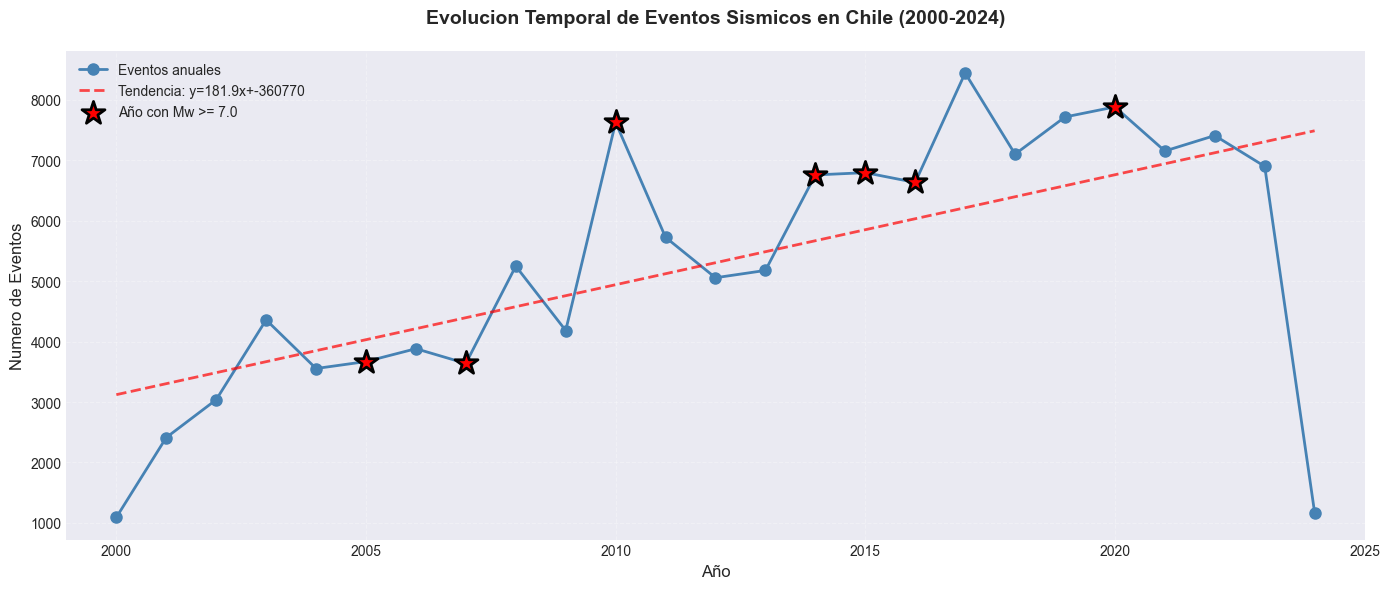

Año con mayor actividad: 2017.0 (8445 eventos)
Año con menor actividad: 2000.0 (1092 eventos)
Promedio anual: 5305.7 eventos


In [159]:
# Grafico 1: Serie Temporal de Actividad Sismica (2000-2024)
print('Graficando Serie Temporal de Actividad Sismica...')

# Agrupar por año
eventos_anuales = df_final.groupby('ANIO_UTC').size()

# Crear figura
fig, ax = plt.subplots(figsize=(14, 6))

# Grafico de linea
ax.plot(eventos_anuales.index, eventos_anuales.values, 
        marker='o', linewidth=2, markersize=8, color='steelblue', label='Eventos anuales')

# Linea de tendencia
z = np.polyfit(eventos_anuales.index, eventos_anuales.values, 1)
p = np.poly1d(z)
ax.plot(eventos_anuales.index, p(eventos_anuales.index), 
        "r--", linewidth=2, alpha=0.7, label=f'Tendencia: y={z[0]:.1f}x+{z[1]:.0f}')

# Destacar años con eventos Mw >= 7.0
eventos_mayores = df_final[df_final['MAGNITUD_MW'] >= 7.0].groupby('ANIO_UTC').size()
for anio, count in eventos_mayores.items():
    if anio in eventos_anuales.index:
        ax.scatter(anio, eventos_anuales[anio], s=300, color='red', 
                  marker='*', edgecolors='black', linewidth=2, zorder=5,
                  label='Año con Mw >= 7.0' if anio == eventos_mayores.index[0] else '')

# Personalizacion
ax.set_title('Evolucion Temporal de Eventos Sismicos en Chile (2000-2024)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Numero de Eventos', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(eventos_anuales.index.min() - 1, eventos_anuales.index.max() + 1)

plt.tight_layout()
plt.show()

print(f'Año con mayor actividad: {eventos_anuales.idxmax()} ({eventos_anuales.max()} eventos)')
print(f'Año con menor actividad: {eventos_anuales.idxmin()} ({eventos_anuales.min()} eventos)')
print(f'Promedio anual: {eventos_anuales.mean():.1f} eventos')

## 4.2 Distribucion de Magnitud MW (Ley de Gutenberg-Richter)

Graficando Distribucion de Magnitud MW...


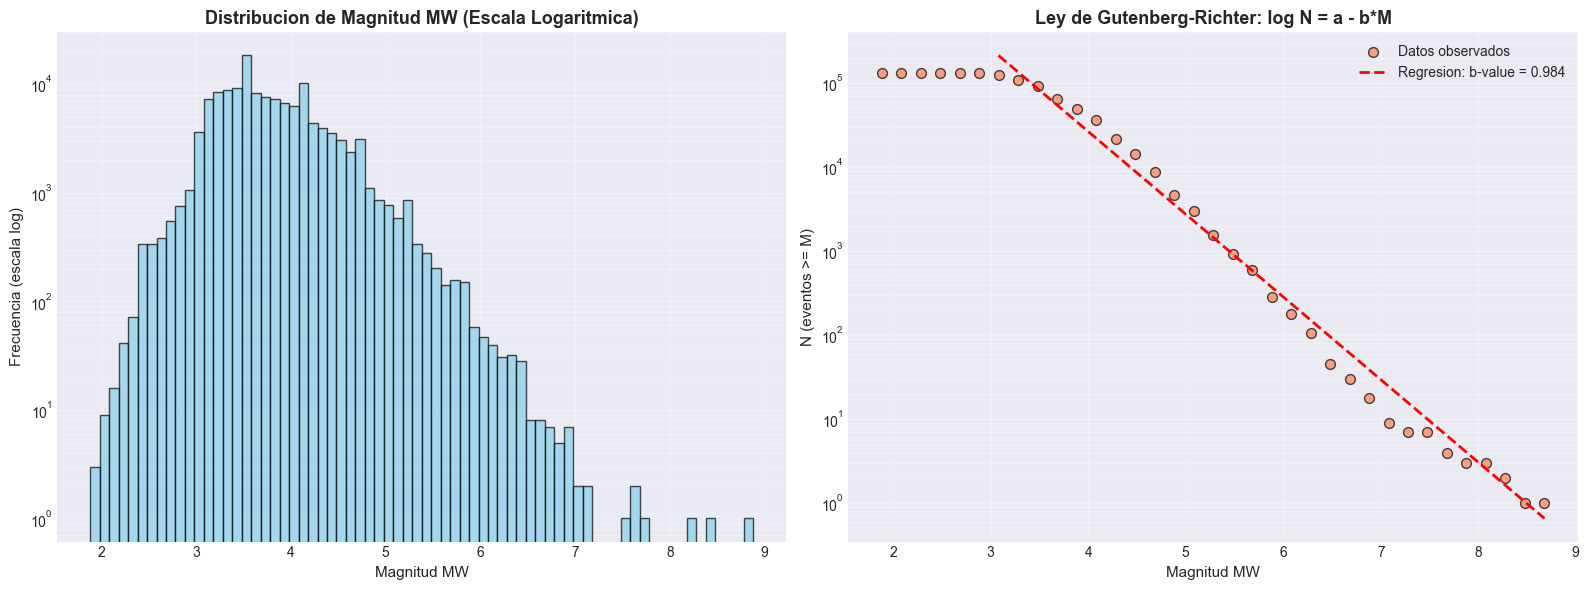

b-value estimado: 0.984 (tipicamente entre 0.8-1.2)
Magnitud mas frecuente: 3.50 Mw
Eventos con Mw >= 7.0: 11


In [160]:
# Grafico 2: Distribucion de Magnitud MW con Ley de Gutenberg-Richter
print('Graficando Distribucion de Magnitud MW...')

# Preparar datos
magnitudes = df_final['MAGNITUD_MW'].dropna()
magnitud_bins = np.arange(magnitudes.min(), magnitudes.max() + 0.1, 0.1)

# Crear figura con 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Histograma con escala logaritmica
counts, bins, patches = ax1.hist(magnitudes, bins=magnitud_bins, 
                                  edgecolor='black', alpha=0.7, color='skyblue')
ax1.set_yscale('log')
ax1.set_title('Distribucion de Magnitud MW (Escala Logaritmica)', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Magnitud MW', fontsize=11)
ax1.set_ylabel('Frecuencia (escala log)', fontsize=11)
ax1.grid(True, alpha=0.3, which='both')

# Subplot 2: Ley de Gutenberg-Richter (log N vs M)
mag_range = np.arange(magnitudes.min(), magnitudes.max(), 0.2)
freq_acumulada = [len(magnitudes[magnitudes >= m]) for m in mag_range]

# Filtrar para regresion (solo magnitudes > Mc estimada)
mc_estimada = 3.0
mask = mag_range >= mc_estimada
mag_filtrado = mag_range[mask]
freq_filtrado = np.array(freq_acumulada)[mask]

# Regresion lineal log(N) = a - b*M
log_freq = np.log10(freq_filtrado + 1)
z = np.polyfit(mag_filtrado, log_freq, 1)
b_value = -z[0]

ax2.scatter(mag_range, freq_acumulada, s=50, alpha=0.7, 
           edgecolors='black', linewidth=1, color='coral', label='Datos observados')
ax2.plot(mag_filtrado, 10**(z[1] + z[0] * mag_filtrado), 
        'r--', linewidth=2, label=f'Regresion: b-value = {b_value:.3f}')
ax2.set_yscale('log')
ax2.set_title('Ley de Gutenberg-Richter: log N = a - b*M', 
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Magnitud MW', fontsize=11)
ax2.set_ylabel('N (eventos >= M)', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f'b-value estimado: {b_value:.3f} (tipicamente entre 0.8-1.2)')
print(f'Magnitud mas frecuente: {magnitudes.mode()[0]:.2f} Mw')
print(f'Eventos con Mw >= 7.0: {len(magnitudes[magnitudes >= 7.0])}')

## 4.3 Mapa de Epicentros (Heatmap Geografico)

Graficando Mapa de Epicentros...


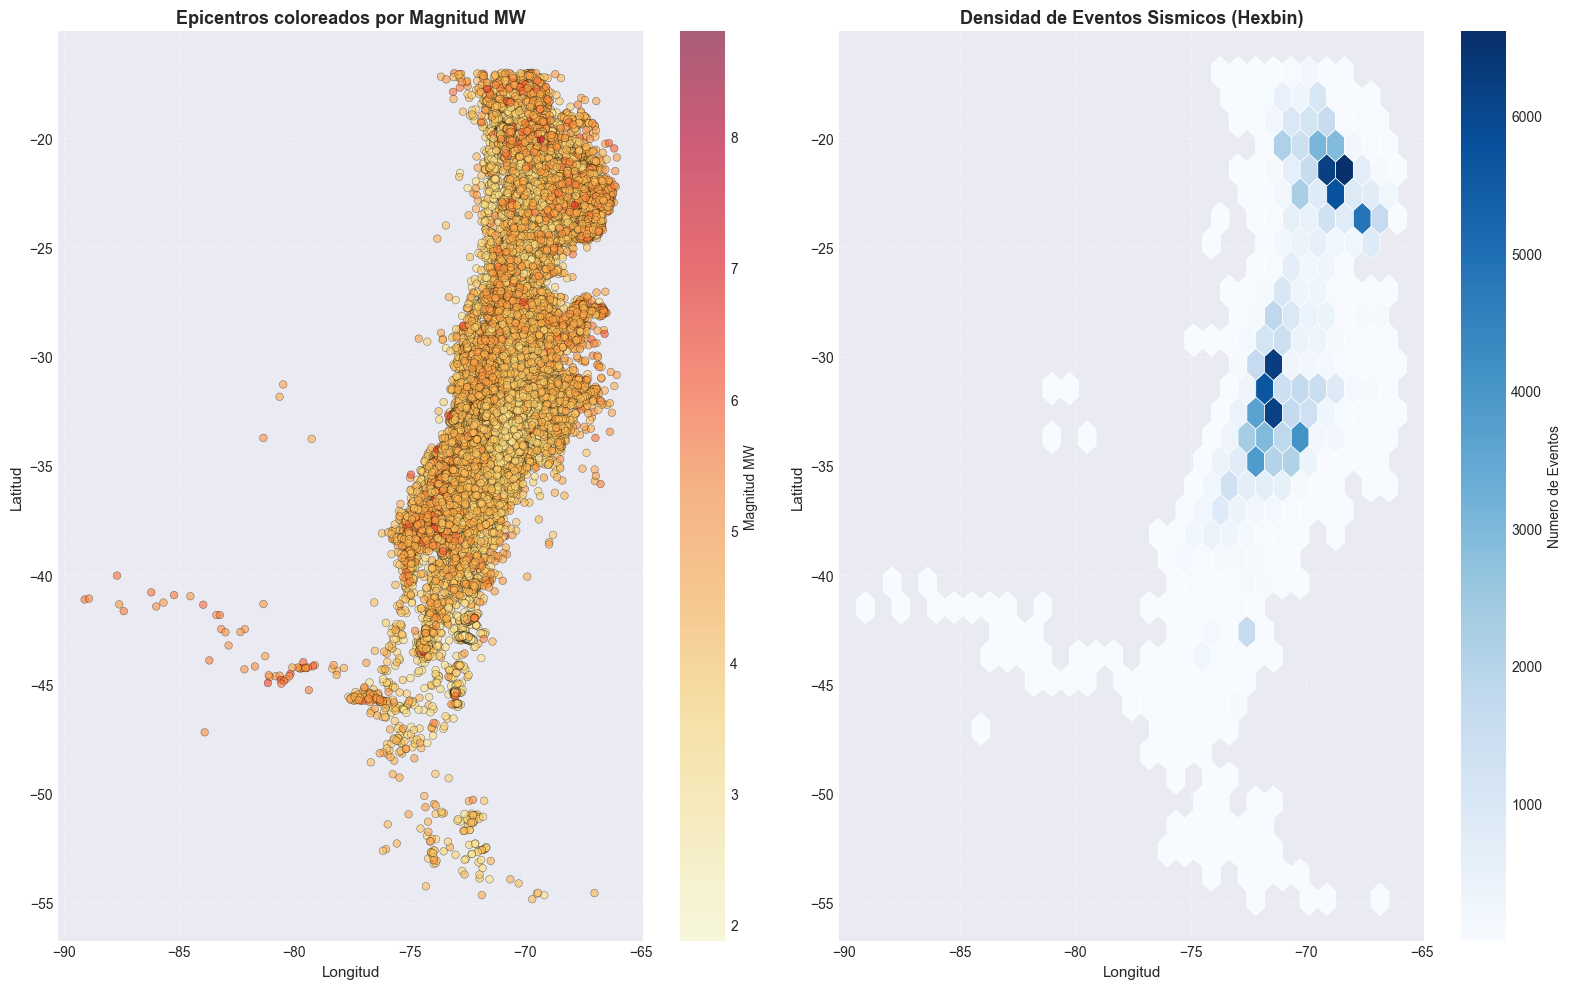


Distribucion geografica:
Zona Norte (> -27°): 57089 eventos (43.0%)
Zona Centro (-27° a -37°): 69670 eventos (52.5%)
Zona Sur (< -37°): 5883 eventos (4.4%)


In [161]:
# Grafico 3: Mapa de Epicentros de Chile
print('Graficando Mapa de Epicentros...')

# Crear figura con 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

# Subplot 1: Scatter plot con color por magnitud
scatter1 = ax1.scatter(df_final['LONGITUD'], df_final['LATITUD'], 
                       c=df_final['MAGNITUD_MW'], cmap='YlOrRd', 
                       s=30, alpha=0.6, edgecolors='black', linewidth=0.3)
ax1.set_title('Epicentros coloreados por Magnitud MW', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Longitud', fontsize=11)
ax1.set_ylabel('Latitud', fontsize=11)
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Magnitud MW', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Subplot 2: Hexbin heatmap (densidad de eventos)
hexbin = ax2.hexbin(df_final['LONGITUD'], df_final['LATITUD'], 
                    gridsize=30, cmap='Blues', mincnt=1, edgecolors='white', linewidths=0.5)
ax2.set_title('Densidad de Eventos Sismicos (Hexbin)', 
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Longitud', fontsize=11)
ax2.set_ylabel('Latitud', fontsize=11)
cbar2 = plt.colorbar(hexbin, ax=ax2)
cbar2.set_label('Numero de Eventos', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Analisis por zona geografica
norte = df_final[df_final['LATITUD'] > -27]
centro = df_final[(df_final['LATITUD'] <= -27) & (df_final['LATITUD'] > -37)]
sur = df_final[df_final['LATITUD'] <= -37]

print(f'\nDistribucion geografica:')
print(f'Zona Norte (> -27°): {len(norte)} eventos ({100*len(norte)/len(df_final):.1f}%)')
print(f'Zona Centro (-27° a -37°): {len(centro)} eventos ({100*len(centro)/len(df_final):.1f}%)')
print(f'Zona Sur (< -37°): {len(sur)} eventos ({100*len(sur)/len(df_final):.1f}%)')

## 4.4 Relacion Profundidad vs Magnitud

Graficando Relacion Profundidad vs Magnitud...


C:\Users\UsuarioCompuElite\AppData\Local\Temp\ipykernel_23816\3613005334.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot_violin, x='CATEGORIA_PROFUNDIDAD', y='MAGNITUD_MW',


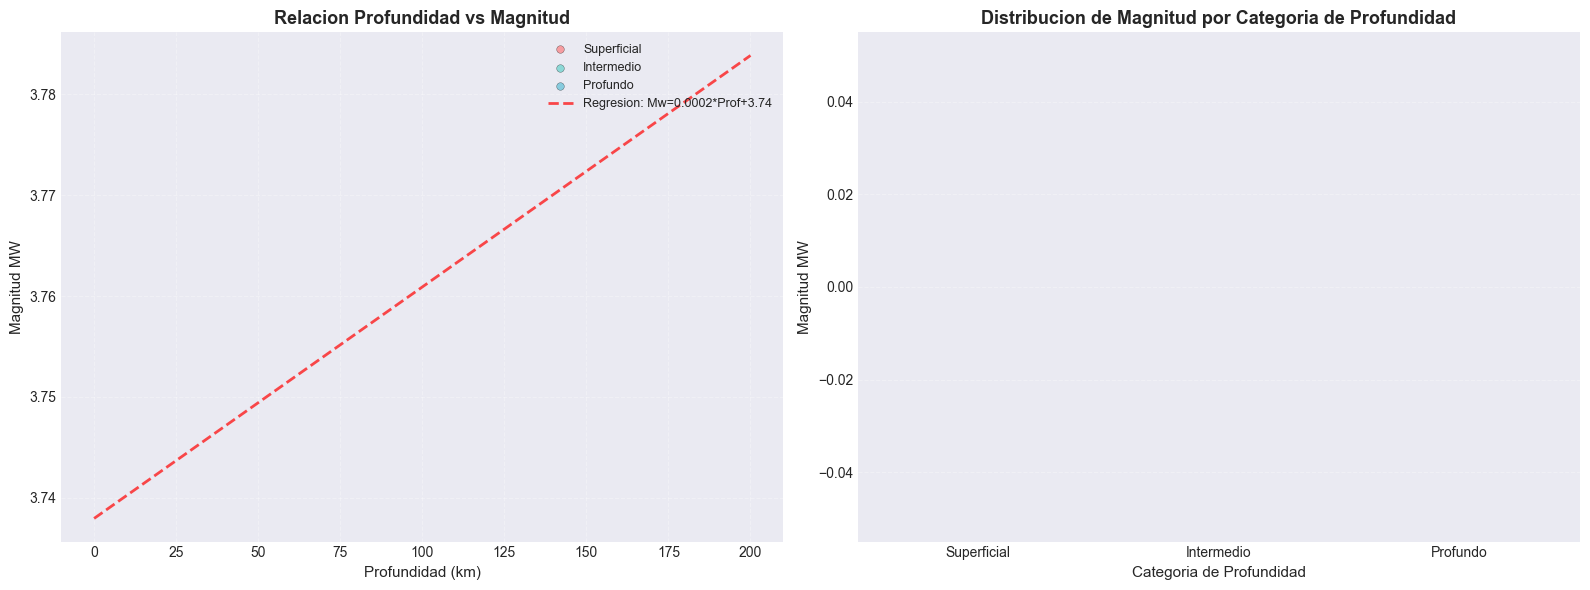


Estadisticas de Magnitud por Categoria de Profundidad:


In [162]:
# Grafico 4: Relacion Profundidad vs Magnitud
print('Graficando Relacion Profundidad vs Magnitud...')

# Preparar datos
df_plot = df_final[['PROFUNDIDAD_VALOR', 'MAGNITUD_MW', 'CATEGORIA_PROFUNDIDAD']].dropna()

# Crear figura con 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Scatter plot con regresion
colores_prof = {'Superficial': '#FF6B6B', 'Intermedio': '#4ECDC4', 'Profundo': '#45B7D1'}
for cat, color in colores_prof.items():
    mask = df_plot['CATEGORIA_PROFUNDIDAD'] == cat
    ax1.scatter(df_plot[mask]['PROFUNDIDAD_VALOR'], 
               df_plot[mask]['MAGNITUD_MW'],
               c=color, label=cat, alpha=0.6, s=30, edgecolors='black', linewidth=0.3)

# Linea de regresion
mask_regresion = df_plot['PROFUNDIDAD_VALOR'] <= 200  # Solo someros e intermedios
z = np.polyfit(df_plot[mask_regresion]['PROFUNDIDAD_VALOR'], 
               df_plot[mask_regresion]['MAGNITUD_MW'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 200, 100)
ax1.plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.7,
         label=f'Regresion: Mw={z[0]:.4f}*Prof+{z[1]:.2f}')

ax1.set_title('Relacion Profundidad vs Magnitud', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Profundidad (km)', fontsize=11)
ax1.set_ylabel('Magnitud MW', fontsize=11)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')

# Subplot 2: Violin plot por categoria de profundidad
df_plot_violin = df_plot[df_plot['CATEGORIA_PROFUNDIDAD'].notna()]
sns.violinplot(data=df_plot_violin, x='CATEGORIA_PROFUNDIDAD', y='MAGNITUD_MW', 
               ax=ax2, palette=colores_prof, order=['Superficial', 'Intermedio', 'Profundo'])
ax2.set_title('Distribucion de Magnitud por Categoria de Profundidad', 
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Categoria de Profundidad', fontsize=11)
ax2.set_ylabel('Magnitud MW', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.show()

# Estadisticas por categoria
print('\nEstadisticas de Magnitud por Categoria de Profundidad:')
for cat in ['Superficial', 'Intermedio', 'Profundo']:
    datos_cat = df_plot[df_plot['CATEGORIA_PROFUNDIDAD'] == cat]['MAGNITUD_MW']
    if len(datos_cat) > 0:
        print(f'{cat}: Media={datos_cat.mean():.2f}, Max={datos_cat.max():.2f}, N={len(datos_cat)}')

## 4.5 Distribucion de Profundidad (Histograma con KDE)

Graficando Distribucion de Profundidad...


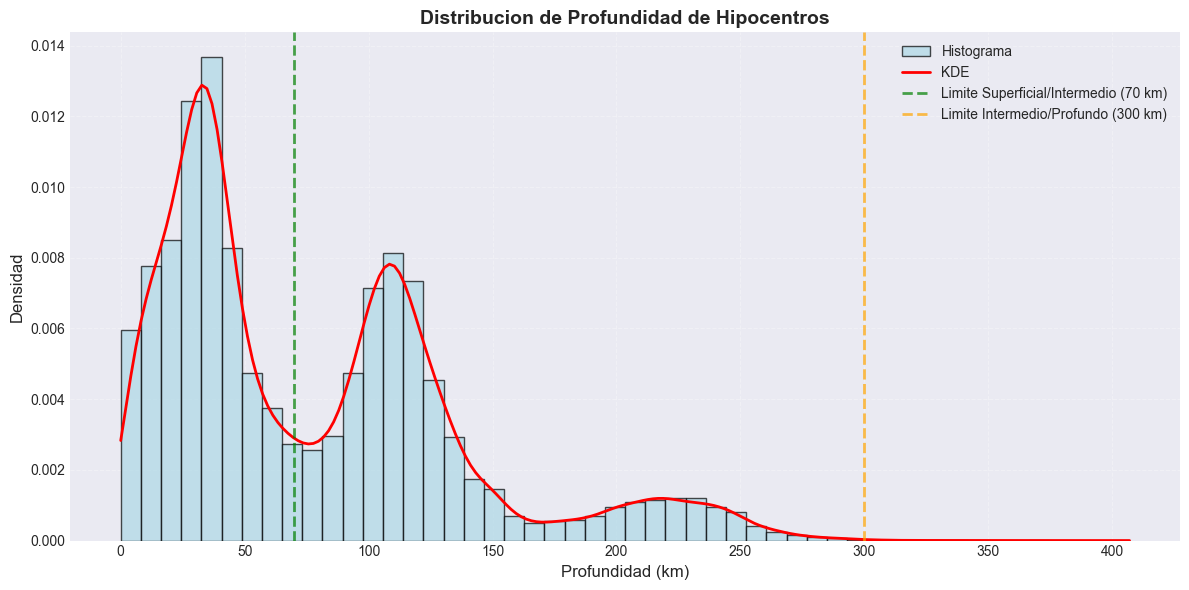


Estadisticas de Profundidad:
Media: 77.0 km
Mediana: 57.0 km
Moda: 15.0 km
Desv. Std: 60.2 km
Rango: [0.0, 407.0] km


In [163]:
# Grafico 5: Distribucion de Profundidad con KDE
print('Graficando Distribucion de Profundidad...')

# Preparar datos
profundidades = df_final['PROFUNDIDAD_VALOR'].dropna()

# Crear figura
fig, ax = plt.subplots(figsize=(12, 6))

# Histograma
ax.hist(profundidades, bins=50, density=True, alpha=0.7, 
        color='lightblue', edgecolor='black', label='Histograma')

# Curva KDE
from scipy.stats import gaussian_kde
kde = gaussian_kde(profundidades)
x_kde = np.linspace(profundidades.min(), profundidades.max(), 200)
ax.plot(x_kde, kde(x_kde), 'r-', linewidth=2, label='KDE')

# Lineas verticales para categorias
ax.axvline(x=70, color='green', linestyle='--', linewidth=2, alpha=0.7, 
          label='Limite Superficial/Intermedio (70 km)')
ax.axvline(x=300, color='orange', linestyle='--', linewidth=2, alpha=0.7, 
          label='Limite Intermedio/Profundo (300 km)')

# Personalizacion
ax.set_title('Distribucion de Profundidad de Hipocentros', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Profundidad (km)', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Estadisticas
print(f'\nEstadisticas de Profundidad:')
print(f'Media: {profundidades.mean():.1f} km')
print(f'Mediana: {profundidades.median():.1f} km')
print(f'Moda: {profundidades.mode()[0]:.1f} km')
print(f'Desv. Std: {profundidades.std():.1f} km')
print(f'Rango: [{profundidades.min():.1f}, {profundidades.max():.1f}] km')

## 4.6 Categorizacion por Magnitud (Grafico de Barras)

Graficando Categorizacion por Magnitud...


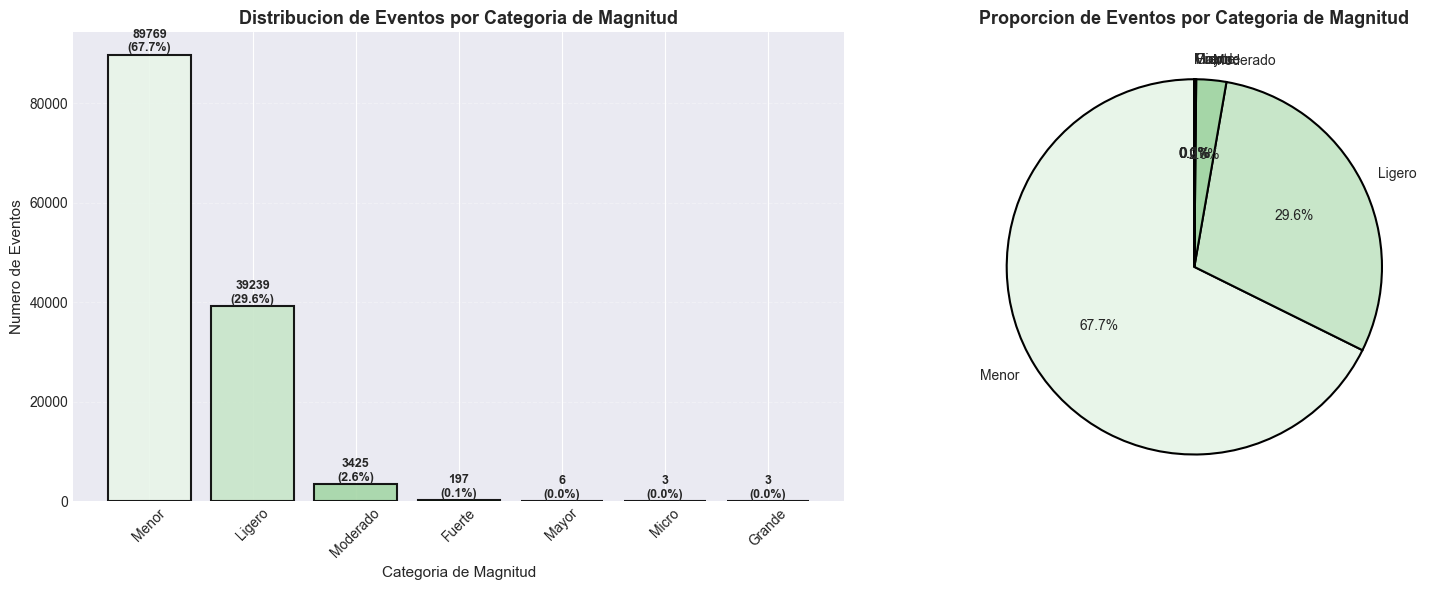


Resumen de Categorizacion:
Menor: 89769 eventos (67.7%)
Ligero: 39239 eventos (29.6%)
Moderado: 3425 eventos (2.6%)
Fuerte: 197 eventos (0.1%)
Mayor: 6 eventos (0.0%)
Micro: 3 eventos (0.0%)
Grande: 3 eventos (0.0%)


In [164]:
# Grafico 6: Categorizacion por Magnitud
print('Graficando Categorizacion por Magnitud...')

# Preparar datos
conteo_mag = df_final['CATEGORIA_MAGNITUD'].value_counts()
porcentaje_mag = (conteo_mag / conteo_mag.sum() * 100).round(1)

# Crear figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Grafico de barras
colores_magnitud = ['#e8f5e9', '#c8e6c9', '#a5d6a7', '#81c784', '#66bb6a', '#4caf50', '#43a047']
bars = ax1.bar(conteo_mag.index, conteo_mag.values, color=colores_magnitud, 
               edgecolor='black', linewidth=1.5, alpha=0.9)
ax1.set_title('Distribucion de Eventos por Categoria de Magnitud', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Categoria de Magnitud', fontsize=11)
ax1.set_ylabel('Numero de Eventos', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')

# Añadir valores en barras
for i, (bar, val, pct) in enumerate(zip(bars, conteo_mag.values, porcentaje_mag.values)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
            f'{val}\n({pct}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Subplot 2: Grafico de pie
ax2.pie(conteo_mag.values, labels=conteo_mag.index, autopct='%1.1f%%', 
        colors=colores_magnitud, startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
ax2.set_title('Proporcion de Eventos por Categoria de Magnitud', 
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Tabla de resumen
print('\nResumen de Categorizacion:')
for cat in conteo_mag.index:
    count = conteo_mag[cat]
    pct = porcentaje_mag[cat]
    print(f'{cat}: {count} eventos ({pct}%)')

## 4.7 Analisis Regional (Box Plot Norte/Centro/Sur)

Graficando Analisis Regional...


C:\Users\UsuarioCompuElite\AppData\Local\Temp\ipykernel_23816\2413685050.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(datos_boxplot, labels=['Norte', 'Centro', 'Sur'],
C:\Users\UsuarioCompuElite\AppData\Local\Temp\ipykernel_23816\2413685050.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final[df_final['PROFUNDIDAD_VALOR'].notna()],


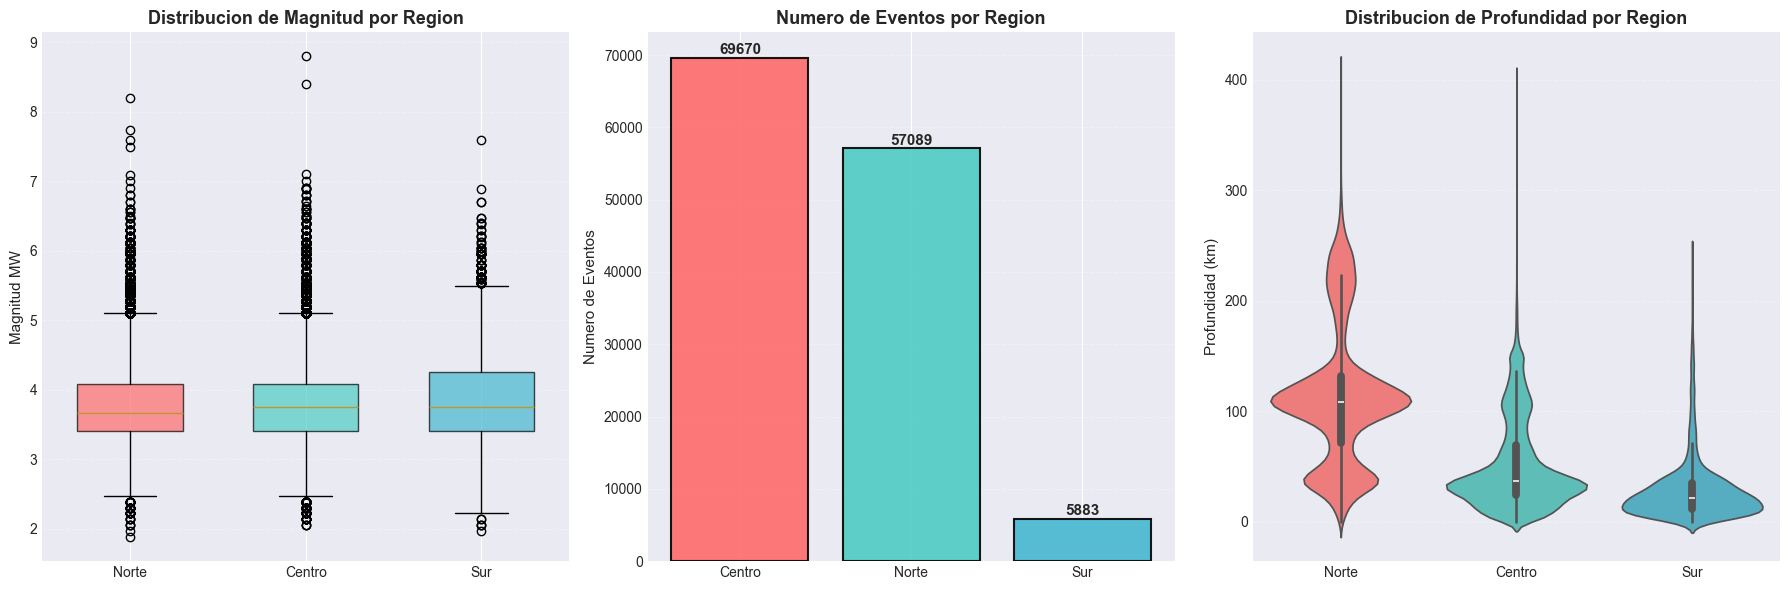


Estadisticas por Region:

Norte:
  Eventos: 57089
  Magnitud media: 3.77
  Magnitud maxima: 8.20
  Profundidad media: 113.6 km

Centro:
  Eventos: 69670
  Magnitud media: 3.78
  Magnitud maxima: 8.80
  Profundidad media: 51.1 km

Sur:
  Eventos: 5883
  Magnitud media: 3.84
  Magnitud maxima: 7.60
  Profundidad media: 28.7 km


In [165]:
# Grafico 7: Analisis Regional (Norte/Centro/Sur)
print('Graficando Analisis Regional...')

# Crear columna de region
def asignar_region(lat):
    if lat > -27:
        return 'Norte'
    elif lat > -37:
        return 'Centro'
    else:
        return 'Sur'

df_final['REGION'] = df_final['LATITUD'].apply(asignar_region)

# Crear figura con 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Box plot de magnitud por region
colores_box = ['#FF6B6B', '#4ECDC4', '#45B7D1']
datos_boxplot = [df_final[df_final['REGION'] == r]['MAGNITUD_MW'].dropna() 
                 for r in ['Norte', 'Centro', 'Sur']]
bp = ax1.boxplot(datos_boxplot, labels=['Norte', 'Centro', 'Sur'], 
                 patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_title('Distribucion de Magnitud por Region', 
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Magnitud MW', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')

# Subplot 2: Numero de eventos por region
conteo_region = df_final['REGION'].value_counts()
bars = ax2.bar(conteo_region.index, conteo_region.values, 
               color=colores_box, edgecolor='black', linewidth=1.5, alpha=0.9)
ax2.set_title('Numero de Eventos por Region', 
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Numero de Eventos', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
for bar, val in zip(bars, conteo_region.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
            f'{val}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Subplot 3: Violin plot de profundidad por region
sns.violinplot(data=df_final[df_final['PROFUNDIDAD_VALOR'].notna()], 
               x='REGION', y='PROFUNDIDAD_VALOR', ax=ax3,
               palette=colores_box, order=['Norte', 'Centro', 'Sur'])
ax3.set_title('Distribucion de Profundidad por Region', 
              fontsize=13, fontweight='bold')
ax3.set_ylabel('Profundidad (km)', fontsize=11)
ax3.set_xlabel('')
ax3.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.show()

# Estadisticas por region
print('\nEstadisticas por Region:')
for region in ['Norte', 'Centro', 'Sur']:
    datos_region = df_final[df_final['REGION'] == region]
    print(f'\n{region}:')
    print(f'  Eventos: {len(datos_region)}')
    print(f'  Magnitud media: {datos_region["MAGNITUD_MW"].mean():.2f}')
    print(f'  Magnitud maxima: {datos_region["MAGNITUD_MW"].max():.2f}')
    print(f'  Profundidad media: {datos_region["PROFUNDIDAD_VALOR"].mean():.1f} km')

## 4.8 Matriz de Correlacion (Heatmap)

Graficando Matriz de Correlacion...


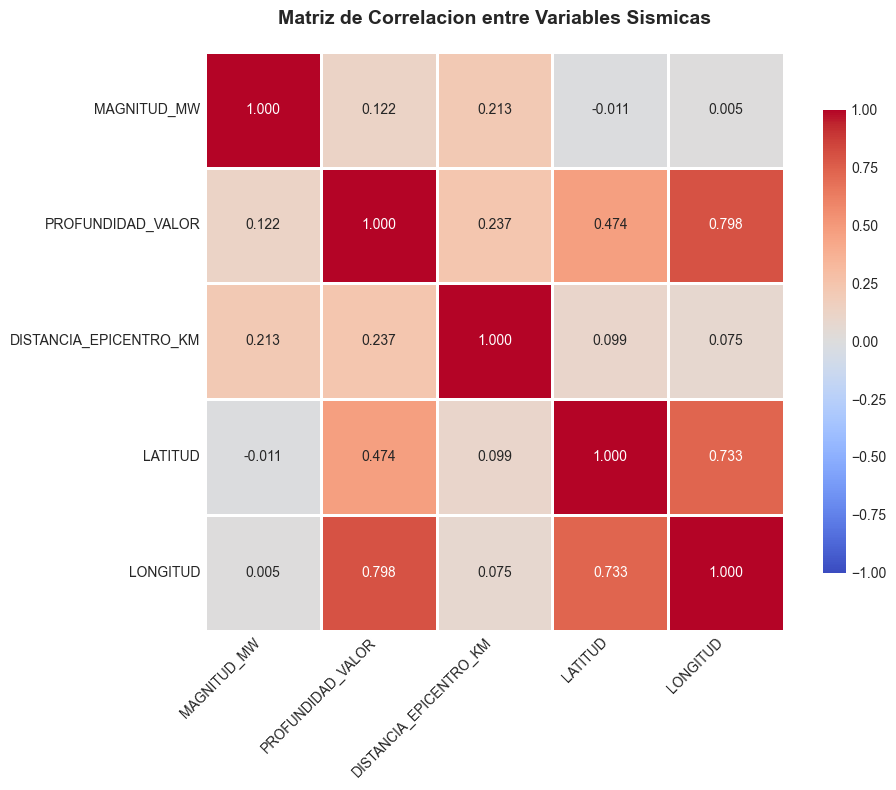


Correlaciones mas fuertes (|r| > 0.3):
  PROFUNDIDAD_VALOR vs LATITUD: 0.474
  PROFUNDIDAD_VALOR vs LONGITUD: 0.798
  LATITUD vs LONGITUD: 0.733

Promedio de correlaciones absolutas: 0.277
Correlacion mas fuerte: 0.798


In [166]:
# Grafico 8: Matriz de Correlacion
print('Graficando Matriz de Correlacion...')

# Seleccionar variables numericas clave
variables_correlacion = ['MAGNITUD_MW', 'PROFUNDIDAD_VALOR', 
                         'DISTANCIA_EPICENTRO_KM', 'LATITUD', 'LONGITUD']

# Crear dataframe con variables seleccionadas (sin valores nulos)
df_corr = df_final[variables_correlacion].dropna()

# Calcular matriz de correlacion
matriz_corr = df_corr.corr()

# Crear figura
fig, ax = plt.subplots(figsize=(10, 8))

# Crear heatmap
sns.heatmap(matriz_corr, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Matriz de Correlacion entre Variables Sismicas', 
             fontsize=14, fontweight='bold', pad=20)

# Rotar etiquetas para mejor legibilidad
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Identificar correlaciones significativas
print('\nCorrelaciones mas fuertes (|r| > 0.3):')
for i in range(len(matriz_corr.columns)):
    for j in range(i+1, len(matriz_corr.columns)):
        corr_val = matriz_corr.iloc[i, j]
        if abs(corr_val) > 0.3:
            var1 = matriz_corr.columns[i]
            var2 = matriz_corr.columns[j]
            print(f'  {var1} vs {var2}: {corr_val:.3f}')

# Estadisticas basicas de correlacion
print(f'\nPromedio de correlaciones absolutas: {abs(matriz_corr.values[np.triu_indices_from(matriz_corr.values, k=1)]).mean():.3f}')
print(f'Correlacion mas fuerte: {abs(matriz_corr.values[np.triu_indices_from(matriz_corr.values, k=1)]).max():.3f}')